# Combined Cell Line Model: MCF7 + HCC1806 and Binning for cross data generalization 
## Hypoxia / Normoxia Prediction via Stacking Classifiers

---

### Project Overview

This notebook develops and evaluates **two complementary modeling approaches** for predicting the oxygen condition (hypoxia vs. normoxia) of cells from two breast cancer cell lines (**MCF7** and **HCC1806**), using SmartSeq single-cell RNA-sequencing data. We already had models that were trained on MCF7 and predict well on MCF7 and same for HCC1806, we use their hyperparameters for comparison  

| Approach | Goal | Evaluation Strategy |
|----------|------|---------------------|
| **1. Combined (Pooled) Model** | A single model trained on pooled MCF7 + HCC1806 data that predicts well on **both** cell lines. | Train on combined training set; evaluate separately on held-out MCF7 and HCC1806 test sets. |
| **2. Binning-Based Model** | A model designed to **generalize to entirely new, unseen datasets** (e.g., a new cell line) by discretizing gene expression into rank-based quantile bins before classification. | **Leave-One-Dataset-Out (LODO)**: train on one cell line, predict on the other; average both directions. |

### Key Challenge

The two cell lines were sequenced independently and have **different gene sets** (~22,934 genes for MCF7 vs. ~23,396 for HCC1806). To train any cross-cell-line model, we first align the feature spaces to their intersection (~20,500 common genes). 

### Notebook Structure

| Section | Contents |
|---------|----------|
| **Part A: Combined (Pooled) Model** | |
| A.1 Data Loading & Feature Alignment | Load raw expression matrices, transpose, create labels, find common genes |
| A.2 Train/Test Splitting | 50/50 balanced held-out test; pooled training set with cell-line-aware stratification |
| A.3 Hyperparameter Optimization (Optuna) | Bayesian search over scaler, feature count, base estimators, and meta-learner via 5-fold stratified CV |
| A.4 Model Training & Evaluation | Best pipeline on full training data; per-cell-line test evaluation |
| A.5 Second Hyperparameter Set (External Sweep) | Hyperparameters from a separate Optuna sweep evaluated on the same data |
| A.6 Cell-Line-Specific Baselines | Previously tuned per-cell-line stacking models tested on the combined splits |
| **Part B: Binning-Based Model** | |
| B.1 Motivation & Experimental Design | Why binning helps generalization; LODO validation strategy |
| B.2 Raw Cross-Dataset Transfer (No Binning) | Baseline: train on one cell line, predict the other, without any binning |
| B.3 Binning Implementation & LODO Optuna Sweep | Quantile binning transformer + Optuna optimization of bin count, feature count, and model hyperparameters using LODO score as the objective |
| B.4 Results & Comparison | Binning model vs. cell-line-specific baselines |



In [9]:
# Install required packages
!pip install -q optuna wandb catboost xgboost scikit-learn optuna-integration


[notice] A new release of pip is available: 23.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
import pandas as pd
import numpy as np
import math
import warnings
warnings.filterwarnings('ignore')

# ML imports
from sklearn.model_selection import (
    train_test_split, cross_val_score, cross_val_predict,
    StratifiedKFold
)
from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, RobustScaler, 
    QuantileTransformer, PowerTransformer
)
from sklearn.feature_selection import SelectKBest, f_classif, VarianceThreshold
from sklearn.linear_model import LogisticRegression, LassoCV
from sklearn.svm import SVC
from sklearn.ensemble import (
    StackingClassifier, VotingClassifier, RandomForestClassifier
)
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    f1_score, roc_auc_score
)

# Boosting libraries
import xgboost as xgb
from catboost import CatBoostClassifier

# Hyperparameter optimization
import optuna
from optuna.integration import WeightsAndBiasesCallback

# Experiment tracking
import wandb

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## A.1 Data Loading and Feature Alignment

The raw data consists of two gene expression count matrices (one per cell line), stored as tab-delimited text files with **genes as rows** and **samples as columns**. The processing steps below are:

1. **Load** both matrices (HCC1806: 23,396 genes x 243 samples; MCF7: 22,934 genes x 383 samples).
2. **Create binary labels** from sample names: column names containing `"Hyp"` are labeled **1** (hypoxia), those containing `"Norm"` are labeled **0** (normoxia).
3. **Transpose** each matrix so that samples become rows and genes become columns (the standard ML convention).
4. **Engineer a feature** `PERC_NONZERO_VALUES`: for each sample, the fraction of genes with non-zero expression (scaled by 1000). This captures library complexity / dropout rate.
5. **Align features**: identify the intersection of gene names present in both datasets (~20,500 common genes) and restrict both DataFrames to these shared columns. Genes unique to one cell line are discarded since we need a common feature space for the pooled model.

In [8]:
# =============================================================================
# DATA LOADING - Using your existing approach from Final_Report.ipynb
# =============================================================================

# Load SmartSeq data (genes as rows, samples as columns)
df_hcc1806_raw = pd.read_csv(
    r"C:\Users\avsd8\OneDrive\Desktop\ai_lab\results\HCC1806_SmartS_Unfiltered_Data.txt", 
    delimiter=r"\ ", engine='python', index_col=0
)
df_mcf7_raw = pd.read_csv(
    r"C:\Users\avsd8\OneDrive\Desktop\ai_lab\results\MCF7_SmartS_Unfiltered_Data.txt", 
    delimiter=r"\ ", engine='python', index_col=0
)

print(f"Raw HCC1806 shape (genes x samples): {df_hcc1806_raw.shape}")
print(f"Raw MCF7 shape (genes x samples): {df_mcf7_raw.shape}")

Raw HCC1806 shape (genes x samples): (23396, 243)
Raw MCF7 shape (genes x samples): (22934, 383)


In [9]:
def create_label(df): 
    """Create binary labels based on column names (Hypo=1, Norm=0)"""
    label = []
    for col in df.columns: 
        if "Hyp" in col: 
            label.append(1)
        elif "Norm" in col:
            label.append(0)
    return label

def preprocess_data(df_raw):
    """
    Transpose data so samples are rows and genes are columns.
    Add PERC_NONZERO_VALUES feature and LABEL column.
    """
    # Create labels from column names (before transpose)
    labels = create_label(df_raw)
    
    # Transpose: genes become columns, samples become rows
    df_transposed = df_raw.T.copy()
    
    # Clean column names (gene names)
    df_transposed.columns = [str(col).replace('"', '') for col in df_transposed.columns]
    
    # Add PERC_NONZERO_VALUES feature
    df_transposed["PERC_NONZERO_VALUES"] = [
        1000 * (df_raw[col] > 0).sum() / len(df_raw[col]) 
        for col in df_raw.columns
    ]
    
    # Add LABEL column
    df_transposed["LABEL"] = labels
    
    return df_transposed

# Process both datasets
df_hcc1806 = preprocess_data(df_hcc1806_raw)
df_mcf7 = preprocess_data(df_mcf7_raw)

print(f"Processed HCC1806 shape (samples x features): {df_hcc1806.shape}")
print(f"Processed MCF7 shape (samples x features): {df_mcf7.shape}")
print(f"\nHCC1806 label distribution: {df_hcc1806['LABEL'].value_counts().to_dict()}")
print(f"MCF7 label distribution: {df_mcf7['LABEL'].value_counts().to_dict()}")

Processed HCC1806 shape (samples x features): (243, 23398)
Processed MCF7 shape (samples x features): (383, 22936)

HCC1806 label distribution: {1: 126, 0: 117}
MCF7 label distribution: {0: 192, 1: 191}


In [10]:
def align_features(df1, df2, label_col="LABEL", exclude_cols=None):
    """
    Identify and align common features (genes) between two datasets.
    
    Args:
        df1: First dataframe (MCF7)
        df2: Second dataframe (HCC1806)
        label_col: Name of the label column
        exclude_cols: Additional columns to exclude from feature matching
    
    Returns:
        df1_aligned: First dataframe with only common features
        df2_aligned: Second dataframe with only common features
        common_genes: List of common gene names
    """
    if exclude_cols is None:
        exclude_cols = []
    
    # Columns to exclude from feature matching
    non_feature_cols = {label_col, "PERC_NONZERO_VALUES"} | set(exclude_cols)
    
    # Get feature columns (genes only)
    features1 = set(df1.columns) - non_feature_cols
    features2 = set(df2.columns) - non_feature_cols
    
    # Find common features (genes)
    common_genes = sorted(features1.intersection(features2))
    
    print(f"Total features in MCF7: {len(features1)}")
    print(f"Total features in HCC1806: {len(features2)}")
    print(f"Common features (genes): {len(common_genes)}")
    print(f"Features only in MCF7: {len(features1 - features2)}")
    print(f"Features only in HCC1806: {len(features2 - features1)}")
    
    # Align datasets to common features + metadata columns
    cols_to_use = common_genes + ["PERC_NONZERO_VALUES", label_col]
    df1_aligned = df1[cols_to_use].copy()
    df2_aligned = df2[cols_to_use].copy()
    
    return df1_aligned, df2_aligned, common_genes

# Align features between datasets
df_mcf7_aligned, df_hcc1806_aligned, common_genes = align_features(df_mcf7, df_hcc1806)

print(f"\nAligned MCF7 shape: {df_mcf7_aligned.shape}")
print(f"Aligned HCC1806 shape: {df_hcc1806_aligned.shape}")

Total features in MCF7: 22934
Total features in HCC1806: 23396
Common features (genes): 20500
Features only in MCF7: 2434
Features only in HCC1806: 2896

Aligned MCF7 shape: (383, 20502)
Aligned HCC1806 shape: (243, 20502)


## A.2 Train/Test Splitting Strategy

The goal is to evaluate the combined model fairly on **both** cell lines. The splitting strategy is:

1. **Held-out test set**: 50 samples are drawn from each cell line (100 total), stratified by label to preserve class balance. This 50/50 composition ensures neither cell line dominates the test evaluation.
2. **Pooled training set**: All remaining samples (333 MCF7 + 193 HCC1806 = 526 total) are combined into a single training set. Note the natural imbalance: MCF7 contributes ~63% of training samples.
3. **Stratification labels for CV**: During cross-validation, folds are stratified by a composite label (`"MCF7_0"`, `"MCF7_1"`, `"HCC1806_0"`, `"HCC1806_1"`) to ensure each fold contains a balanced mix of both cell lines *and* both classes. This prevents the optimizer from finding configurations that work well for one cell line but poorly for the other.

In [5]:
# =============================================================================
# DATA SPLITTING: USE ALL DATA, 50/50 TEST SET
# =============================================================================

from sklearn.model_selection import train_test_split, StratifiedKFold

RANDOM_STATE = 42

# Get feature columns (excluding LABEL)
feature_cols = [col for col in df_mcf7_aligned.columns if col not in ["LABEL"]]

# =============================================================================
# EXTRACT FULL DATASETS
# =============================================================================
X_mcf7_full = df_mcf7_aligned[feature_cols].values.astype(np.float32)
y_mcf7_full = df_mcf7_aligned["LABEL"].values.astype(np.int32)

X_hcc1806_full = df_hcc1806_aligned[feature_cols].values.astype(np.float32)
y_hcc1806_full = df_hcc1806_aligned["LABEL"].values.astype(np.int32)

print(f"Full MCF7: {len(y_mcf7_full)} samples")
print(f"Full HCC1806: {len(y_hcc1806_full)} samples")
print(f"Total: {len(y_mcf7_full) + len(y_hcc1806_full)} samples")

# =============================================================================
# CREATE 50/50 BALANCED TEST SET (equal samples from each dataset)
# =============================================================================
TEST_SAMPLES_PER_DATASET = 50  # 50 from each = 100 total test (50/50)

# Split MCF7
X_mcf7_train, X_mcf7_test, y_mcf7_train, y_mcf7_test = train_test_split(
    X_mcf7_full, y_mcf7_full,
    test_size=TEST_SAMPLES_PER_DATASET,
    stratify=y_mcf7_full,
    random_state=RANDOM_STATE
)

# Split HCC1806
X_hcc1806_train, X_hcc1806_test, y_hcc1806_train, y_hcc1806_test = train_test_split(
    X_hcc1806_full, y_hcc1806_full,
    test_size=TEST_SAMPLES_PER_DATASET,
    stratify=y_hcc1806_full,
    random_state=RANDOM_STATE
)

# =============================================================================
# COMBINE ALL TRAINING DATA (no undersampling)
# =============================================================================
X_combined_train = np.vstack([X_mcf7_train, X_hcc1806_train])
y_combined_train = np.concatenate([y_mcf7_train, y_hcc1806_train])

# Create stratification labels for CV
source_train = np.array(['MCF7'] * len(y_mcf7_train) + ['HCC1806'] * len(y_hcc1806_train))
stratify_labels_train = np.array([f"{src}_{lab}" for src, lab in zip(source_train, y_combined_train)])

# =============================================================================
# PRINT SUMMARY
# =============================================================================
print("\n" + "=" * 60)
print("TEST SET (50/50 Balanced)")
print("=" * 60)
print(f"MCF7 Test:    {len(y_mcf7_test)} samples (Norm: {sum(y_mcf7_test==0)}, Hypo: {sum(y_mcf7_test==1)})")
print(f"HCC1806 Test: {len(y_hcc1806_test)} samples (Norm: {sum(y_hcc1806_test==0)}, Hypo: {sum(y_hcc1806_test==1)})")
print(f"Total Test:   {len(y_mcf7_test) + len(y_hcc1806_test)} samples")

mcf7_pct = len(y_mcf7_train) / len(y_combined_train) * 100
hcc_pct = len(y_hcc1806_train) / len(y_combined_train) * 100

print("\n" + "=" * 60)
print("TRAINING SET (All Data)")
print("=" * 60)
print(f"MCF7:    {len(y_mcf7_train)} samples ({mcf7_pct:.1f}%) (Norm: {sum(y_mcf7_train==0)}, Hypo: {sum(y_mcf7_train==1)})")
print(f"HCC1806: {len(y_hcc1806_train)} samples ({hcc_pct:.1f}%) (Norm: {sum(y_hcc1806_train==0)}, Hypo: {sum(y_hcc1806_train==1)})")
print(f"Total:   {len(y_combined_train)} samples")

print("\n" + "=" * 60)
print("SUMMARY")
print("=" * 60)
print(f"Training: {len(y_combined_train)} samples (MCF7: {len(y_mcf7_train)}, HCC1806: {len(y_hcc1806_train)})")
print(f"Test:     {len(y_mcf7_test) + len(y_hcc1806_test)} samples (MCF7: {len(y_mcf7_test)}, HCC1806: {len(y_hcc1806_test)}) - 50/50")
print(f"Total used: {len(y_combined_train) + len(y_mcf7_test) + len(y_hcc1806_test)} samples (ALL DATA)")

# Store max features for objective function
MAX_FEATURES = X_combined_train.shape[1] - 1

Full MCF7: 383 samples
Full HCC1806: 243 samples
Total: 626 samples

TEST SET (50/50 Balanced)
MCF7 Test:    50 samples (Norm: 25, Hypo: 25)
HCC1806 Test: 50 samples (Norm: 24, Hypo: 26)
Total Test:   100 samples

TRAINING SET (All Data)
MCF7:    333 samples (63.3%) (Norm: 167, Hypo: 166)
HCC1806: 193 samples (36.7%) (Norm: 93, Hypo: 100)
Total:   526 samples

SUMMARY
Training: 526 samples (MCF7: 333, HCC1806: 193)
Test:     100 samples (MCF7: 50, HCC1806: 50) - 50/50
Total used: 626 samples (ALL DATA)


## A.3 Hyperparameter Optimization with Optuna

### Why Hyperparameter Optimization Matters Here

With ~20,500 features and only 526 training samples, the model is highly sensitive to configuration choices: which scaler to use, how many genes to keep, which base estimators to include, and what regularization strengths to set. Manual tuning is infeasible given the combinatorial search space, so we use **Optuna** (a Bayesian optimization framework using the Tree-structured Parzen Estimator sampler) to automatically find the best configuration.

### Search Space

The Optuna objective function explores the following hyperparameters:

| Category | Parameter | Range / Options |
|----------|-----------|----------------|
| **Preprocessing** | Scaler | `none`, `standard`, `minmax`, `robust`, `quantile`, `power` |
| | Number of features (SelectKBest with ANOVA F-test) | 50 to 3,000 (step 50) |
| **Model selection** | Include Logistic Regression (L1)? | True / False |
| | Include SVC (RBF kernel)? | True / False |
| | Include XGBoost? | True / False |
| | Include CatBoost? | True / False |
| | Meta-learner | Logistic Regression (L2) or Random Forest |
| **LR hyperparams** | C (inverse regularization) | 0.01 -- 10.0 (log scale) |
| **SVC hyperparams** | C | 0.1 -- 100.0 (log); gamma | 1e-4 -- 0.1 (log) |
| **XGBoost hyperparams** | max_depth (2--4), learning_rate (0.1--0.5), n_estimators (100--600), L1/L2 reg (0.1--10.0) |
| **CatBoost hyperparams** | depth (2--6), learning_rate (0.1--0.5), iterations (100--600), L2 reg (1.0--10.0) |

A trial is **pruned** if fewer than 2 base estimators are selected (stacking requires at least 2).

### Evaluation: 5-Fold Stratified Cross-Validation

Each trial builds the full pipeline (scaler &rarr; SelectKBest &rarr; StackingClassifier) and evaluates it via **5-fold stratified CV on the pooled training set**. Crucially, the stratification uses the composite cell-line + label key to keep each fold balanced across both datasets. Feature selection is performed **within** each fold to avoid data leakage.

The objective is **mean accuracy** across the 5 folds

### Implementation

The next two code cells define:
1. `create_stacking_classifier(params)` -- factory function that assembles a `StackingClassifier` from the trial's parameter dictionary.
2. `objective(trial)` -- the Optuna objective function that builds a pipeline, runs 5-fold CV, and returns the mean accuracy.

### Stacking Classifier Factory & Objective Function

The `create_stacking_classifier` function below assembles a `StackingClassifier` from the hyperparameter dictionary produced by each Optuna trial. The `objective` function then wraps the full pipeline (scaler selection, feature selection, stacking classifier) and runs 5-fold stratified CV.

In [14]:
def create_stacking_classifier(params):
    """
    Create a stacking classifier with given hyperparameters.
    
    Args:
        params: Dictionary of hyperparameters
    
    Returns:
        StackingClassifier instance
    """
    estimators = []
    
    # Logistic Regression (L1 for sparsity)
    if params.get("use_lr", True):
        lr = LogisticRegression(
            penalty="l1",
            solver="saga",
            C=params.get("lr_C", 1.0),
            max_iter=1000,
            random_state=RANDOM_STATE
        )
        estimators.append(("lr", lr))
    
    # SVM with RBF kernel
    if params.get("use_svc", True):
        svc = SVC(
            probability=True,
            C=params.get("svc_C", 1.0),
            gamma=params.get("svc_gamma", "scale"),
            random_state=RANDOM_STATE
        )
        estimators.append(("svc", svc))
    
    # XGBoost
    if params.get("use_xgb", True):
        xgb_clf = xgb.XGBClassifier(
            max_depth=params.get("xgb_depth", 2),
            learning_rate=params.get("xgb_lr", 0.3),
            n_estimators=params.get("xgb_n_estimators", 300),
            reg_alpha=params.get("xgb_reg_alpha", 1.0),
            reg_lambda=params.get("xgb_reg_lambda", 1.0),
            objective="binary:logistic",
            tree_method="hist",
            random_state=RANDOM_STATE,
            verbosity=0
        )
        estimators.append(("xgb", xgb_clf))
    
    # CatBoost
    if params.get("use_cbc", True):
        cbc = CatBoostClassifier(
            depth=params.get("cbc_depth", 4),
            learning_rate=params.get("cbc_lr", 0.3),
            iterations=params.get("cbc_iterations", 300),
            l2_leaf_reg=params.get("cbc_l2_reg", 3.0),
            random_state=RANDOM_STATE,
            verbose=False
        )
        estimators.append(("cbc", cbc))
    
    # Final estimator (meta-learner)
    final_estimator_type = params.get("final_estimator", "lr")
    if final_estimator_type == "lr":
        final_estimator = LogisticRegression(
            penalty="l2",
            max_iter=1000,
            random_state=RANDOM_STATE
        )
    else:
        final_estimator = RandomForestClassifier(
            n_estimators=100,
            max_depth=3,
            random_state=RANDOM_STATE
        )
    
    stacking_clf = StackingClassifier(
        estimators=estimators,
        final_estimator=final_estimator,
        cv=5,
        n_jobs=-1
    )
    
    return stacking_clf

In [15]:
# =============================================================================
# OBJECTIVE FUNCTION: 5-FOLD STRATIFIED CV ON COMBINED TRAINING SET
# =============================================================================

def get_scaler(scaler_name):
    """
    Returns the appropriate scaler based on name.
    """
    scalers = {
        "none": "passthrough",
        "standard": StandardScaler(),
        "minmax": MinMaxScaler(),
        "robust": RobustScaler(),
        "quantile": QuantileTransformer(output_distribution="normal", random_state=RANDOM_STATE),
        "power": PowerTransformer(method="yeo-johnson", standardize=True),
    }
    return scalers.get(scaler_name, StandardScaler())

def objective(trial):
    """
    Optuna objective function for hyperparameter optimization.
    Uses 5-fold stratified CV on the combined training set.
    """
    # ==========================================================================
    # PREPROCESSING HYPERPARAMETERS
    # ==========================================================================
    
    scaler_name = trial.suggest_categorical(
        "scaler", 
        ["none", "standard", "minmax", "robust", "quantile", "power"]
    )
    
    n_features = trial.suggest_int("n_features", 50, min(3000, MAX_FEATURES), step=50)
    
    # ==========================================================================
    # MODEL SELECTION HYPERPARAMETERS
    # ==========================================================================
    
    use_lr = trial.suggest_categorical("use_lr", [True, False])
    use_svc = trial.suggest_categorical("use_svc", [True, False])
    use_xgb = trial.suggest_categorical("use_xgb", [True, False])
    use_cbc = trial.suggest_categorical("use_cbc", [True, False])
    
    if sum([use_lr, use_svc, use_xgb, use_cbc]) < 2:
        raise optuna.TrialPruned("Need at least 2 base estimators for stacking")
    
    params = {
        "use_lr": use_lr,
        "use_svc": use_svc,
        "use_xgb": use_xgb,
        "use_cbc": use_cbc,
        "scaler": scaler_name,
    }
    
    if use_lr:
        params["lr_C"] = trial.suggest_float("lr_C", 0.01, 10.0, log=True)
    
    if use_svc:
        params["svc_C"] = trial.suggest_float("svc_C", 0.1, 100.0, log=True)
        params["svc_gamma"] = trial.suggest_float("svc_gamma", 1e-4, 1e-1, log=True)
    
    if use_xgb:
        params["xgb_depth"] = trial.suggest_int("xgb_depth", 2, 4)
        params["xgb_lr"] = trial.suggest_float("xgb_lr", 0.1, 0.5)
        params["xgb_n_estimators"] = trial.suggest_int("xgb_n_estimators", 100, 600, step=50)
        params["xgb_reg_alpha"] = trial.suggest_float("xgb_reg_alpha", 0.1, 10.0, log=True)
        params["xgb_reg_lambda"] = trial.suggest_float("xgb_reg_lambda", 0.1, 10.0, log=True)
    
    if use_cbc:
        params["cbc_depth"] = trial.suggest_int("cbc_depth", 2, 6)
        params["cbc_lr"] = trial.suggest_float("cbc_lr", 0.1, 0.5)
        params["cbc_iterations"] = trial.suggest_int("cbc_iterations", 100, 600, step=50)
        params["cbc_l2_reg"] = trial.suggest_float("cbc_l2_reg", 1.0, 10.0)
    
    params["final_estimator"] = trial.suggest_categorical("final_estimator", ["lr", "rf"])
    
    # ==========================================================================
    # 5-FOLD STRATIFIED CV ON COMBINED TRAINING SET
    # ==========================================================================
    
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    
    try:
        scores = []
        for train_idx, val_idx in cv.split(X_combined_train, stratify_labels_train):
            X_train, X_val = X_combined_train[train_idx], X_combined_train[val_idx]
            y_train, y_val = y_combined_train[train_idx], y_combined_train[val_idx]
            
            pipeline = Pipeline([
                ("scaler", get_scaler(scaler_name)),
                ("selector", SelectKBest(f_classif, k=n_features)),
                ("stacking", create_stacking_classifier(params))
            ])
            pipeline.fit(X_train, y_train)
            scores.append(pipeline.score(X_val, y_val))
        
        mean_score = np.mean(scores)
        trial.set_user_attr("cv_std", np.std(scores))
        
        return mean_score
        
    except Exception as e:
        print(f"Trial failed: {e}")
        raise optuna.TrialPruned(f"Trial failed: {e}")

### Running the Optuna Search

The cell below configures and launches the Optuna study. The search runs for `N_TRIALS` (250) trials. Weights & Biases tracking is available but disabled by default (`USE_WANDB = False`); set it to `True` and run `wandb.login()` to enable experiment logging.

> **Note:** The full 250-trial search is compute-intensive (several hours). The output below shows the trial-by-trial progress. The best trial's hyperparameters are extracted in the subsequent cells.

In [34]:
# Initialize W&B (optional - set to False to skip)
USE_WANDB = False  # Set to True if you want to use Weights & Biases

if USE_WANDB:
    try:
        wandb.login()
        print("W&B login successful")
    except Exception as e:
        print(f"W&B login failed: {e}")
        USE_WANDB = False
else:
    print("W&B disabled. Set USE_WANDB = True to enable experiment tracking.")

W&B disabled. Set USE_WANDB = True to enable experiment tracking.


In [40]:
# =============================================================================
# RUN OPTUNA HYPERPARAMETER SEARCH
# =============================================================================

def run_optuna_study(n_trials=100, use_wandb=False):
    study = optuna.create_study(
        direction="maximize",
        study_name="combined_train_cv",
        sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
    )
    
    callbacks = []
    if use_wandb:
        wandb.init(project="combined-train-cv", config={"n_trials": n_trials}, reinit=True)
        wandb_callback = WeightsAndBiasesCallback(metric_name="cv_accuracy")
        callbacks.append(wandb_callback)
    
    study.optimize(objective, n_trials=n_trials, callbacks=callbacks, show_progress_bar=True)
    
    if use_wandb:
        wandb.finish()
    
    return study

print("=" * 60)
print("HYPERPARAMETER SEARCH: 5-FOLD STRATIFIED CV ON TRAIN SET")
print("=" * 60)
print(f"Training set: {X_combined_train.shape[0]} samples")
print(f"Held-out test: MCF7={len(y_mcf7_test)}, HCC1806={len(y_hcc1806_test)}")
print("=" * 60)

N_TRIALS = 250
study = run_optuna_study(n_trials=N_TRIALS, use_wandb=USE_WANDB)

[I 2026-02-02 15:53:36,734] A new study created in memory with name: combined_train_cv


HYPERPARAMETER SEARCH: 5-FOLD STRATIFIED CV ON TRAIN SET
Training set: 526 samples
Held-out test: MCF7=50, HCC1806=50


Best trial: 0. Best value: 0.960108:   0%|          | 1/250 [00:32<2:16:38, 32.93s/it]

[I 2026-02-02 15:54:09,658] Trial 0 finished with value: 0.9601078167115903 and parameters: {'scaler': 'standard', 'n_features': 200, 'use_lr': True, 'use_svc': True, 'use_xgb': True, 'use_cbc': True, 'lr_C': 0.03549878832196503, 'svc_C': 0.8179499475211672, 'svc_gamma': 0.0037520558551242854, 'xgb_depth': 3, 'xgb_lr': 0.21649165607921678, 'xgb_n_estimators': 400, 'xgb_reg_alpha': 0.19010245319870356, 'xgb_reg_lambda': 0.3839629299804172, 'cbc_depth': 3, 'cbc_lr': 0.28242799368681437, 'cbc_iterations': 500, 'cbc_l2_reg': 2.7970640394252375, 'final_estimator': 'rf'}. Best is trial 0 with value: 0.9601078167115903.


Best trial: 0. Best value: 0.960108:   1%|          | 2/250 [05:53<13:56:03, 202.27s/it]

...

[I 2026-02-03 00:12:08,125] Trial 247 finished with value: 0.9696136567834681 and parameters: {'scaler': 'none', 'n_features': 1000, 'use_lr': True, 'use_svc': True, 'use_xgb': False, 'use_cbc': True, 'lr_C': 4.865883291366694, 'svc_C': 0.8081843745206245, 'svc_gamma': 0.006174674230126834, 'cbc_depth': 2, 'cbc_lr': 0.18998920308182898, 'cbc_iterations': 200, 'cbc_l2_reg': 4.338851368269696, 'final_estimator': 'rf'}. Best is trial 32 with value: 0.9791194968553458.


Best trial: 32. Best value: 0.979119: 100%|█████████▉| 249/250 [8:24:51<02:47, 167.20s/it]

[I 2026-02-03 00:18:27,739] Trial 248 finished with value: 0.9715184186882301 and parameters: {'scaler': 'power', 'n_features': 1050, 'use_lr': True, 'use_svc': True, 'use_xgb': False, 'use_cbc': True, 'lr_C': 5.859115336870266, 'svc_C': 0.5846360232886779, 'svc_gamma': 0.008403655015360405, 'cbc_depth': 2, 'cbc_lr': 0.2046614776764898, 'cbc_iterations': 200, 'cbc_l2_reg': 4.58337058760036, 'final_estimator': 'rf'}. Best is trial 32 with value: 0.9791194968553458.


Best trial: 32. Best value: 0.979119: 100%|██████████| 250/250 [8:26:05<00:00, 121.46s/it]

[I 2026-02-03 00:19:42,615] Trial 249 finished with value: 0.9658580413297395 and parameters: {'scaler': 'none', 'n_features': 950, 'use_lr': True, 'use_svc': True, 'use_xgb': False, 'use_cbc': True, 'lr_C': 7.569317606018416, 'svc_C': 0.6176006876490506, 'svc_gamma': 0.004740320217552903, 'cbc_depth': 2, 'cbc_lr': 0.17857402038931736, 'cbc_iterations': 200, 'cbc_l2_reg': 4.713034071589387, 'final_estimator': 'rf'}. Best is trial 32 with value: 0.9791194968553458.


In [10]:
# Display best results
print("\n" + "="*60)
print("OPTIMIZATION RESULTS")
print("="*60)
print(f"\nBest trial accuracy: {study.best_trial.value:.4f}")
print(f"\nBest hyperparameters:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")


OPTIMIZATION RESULTS


NameError: name 'study' is not defined

## A.4 Best Hyperparameters, Feature Selection & Model Evaluation (Run 1)

The Optuna search identified **Trial 32** as the best configuration (CV accuracy: **97.9%**). The optimal pipeline uses:
- **No scaling** (`scaler = "none"`)
- **1,200 features** selected by ANOVA F-test
- **Base estimators**: Logistic Regression (L1, C=9.81) + SVC (RBF, C=0.48, gamma=0.029) + CatBoost (depth=2, lr=0.20, 200 iterations, L2=5.02)
- **Meta-learner**: Random Forest (100 trees, max_depth=3)

The cells below:
1. Hard-code the best hyperparameters (so the notebook can be re-run without repeating the Optuna search).
2. Apply feature selection on the training data and transform the test sets.
3. Train each base estimator individually to establish baselines.
4. Train the full stacking classifier and compare.

In [ ]:
# =============================================================================
# PREPARE DATA: Apply Feature Selection
# =============================================================================

from sklearn.feature_selection import SelectKBest, f_classif

# Feature selector based on best params
n_features = 1200
selector = SelectKBest(f_classif, k=n_features)

# Fit on training data
selector.fit(X_combined_train, y_combined_train)

# Transform all datasets
X_train_selected = selector.transform(X_combined_train)
X_test_mcf7_selected = selector.transform(X_mcf7_test)
X_test_hcc1806_selected = selector.transform(X_hcc1806_test)

print(f"Feature selection: {X_combined_train.shape[1]} -> {n_features} features")
print(f"\nTraining data shape: {X_train_selected.shape}")
print(f"MCF7 test data shape: {X_test_mcf7_selected.shape}")
print(f"HCC1806 test data shape: {X_test_hcc1806_selected.shape}")

In [18]:
# =============================================================================
# BASELINE COMPARISON: Train each base estimator individually
# =============================================================================

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report

def evaluate_model(model, X_test, y_test, dataset_name):
    """Evaluate a model on a test set and return metrics."""
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba) if y_proba is not None else None
    
    return {'accuracy': acc, 'f1': f1, 'auc': auc}

# Store results
baseline_results = {}

print("=" * 70)
print("INDIVIDUAL BASE MODEL PERFORMANCE (Trained on Combined Train Set)")
print("=" * 70)

# -----------------------------------------------------------------------------
# 1. Logistic Regression
# -----------------------------------------------------------------------------
print("\n" + "-" * 70)
print("1. LOGISTIC REGRESSION (L1)")
print("-" * 70)

lr_model = LogisticRegression(
    penalty="l1",
    solver="saga",
    C=best_params['lr_C'],
    max_iter=1000,
    random_state=RANDOM_STATE
)
lr_model.fit(X_train_selected, y_combined_train)

lr_mcf7 = evaluate_model(lr_model, X_test_mcf7_selected, y_mcf7_test, "MCF7")
lr_hcc1806 = evaluate_model(lr_model, X_test_hcc1806_selected, y_hcc1806_test, "HCC1806")
baseline_results['Logistic Regression'] = {'MCF7': lr_mcf7, 'HCC1806': lr_hcc1806}

print(f"  MCF7 Test:    Accuracy={lr_mcf7['accuracy']:.4f}, F1={lr_mcf7['f1']:.4f}, AUC={lr_mcf7['auc']:.4f}")
print(f"  HCC1806 Test: Accuracy={lr_hcc1806['accuracy']:.4f}, F1={lr_hcc1806['f1']:.4f}, AUC={lr_hcc1806['auc']:.4f}")

# -----------------------------------------------------------------------------
# 2. SVC (RBF Kernel)
# -----------------------------------------------------------------------------
print("\n" + "-" * 70)
print("2. SVC (RBF Kernel)")
print("-" * 70)

svc_model = SVC(
    probability=True,
    C=best_params['svc_C'],
    gamma=best_params['svc_gamma'],
    random_state=RANDOM_STATE
)
svc_model.fit(X_train_selected, y_combined_train)

svc_mcf7 = evaluate_model(svc_model, X_test_mcf7_selected, y_mcf7_test, "MCF7")
svc_hcc1806 = evaluate_model(svc_model, X_test_hcc1806_selected, y_hcc1806_test, "HCC1806")
baseline_results['SVC'] = {'MCF7': svc_mcf7, 'HCC1806': svc_hcc1806}

print(f"  MCF7 Test:    Accuracy={svc_mcf7['accuracy']:.4f}, F1={svc_mcf7['f1']:.4f}, AUC={svc_mcf7['auc']:.4f}")
print(f"  HCC1806 Test: Accuracy={svc_hcc1806['accuracy']:.4f}, F1={svc_hcc1806['f1']:.4f}, AUC={svc_hcc1806['auc']:.4f}")

# -----------------------------------------------------------------------------
# 3. CatBoost
# -----------------------------------------------------------------------------
print("\n" + "-" * 70)
print("3. CATBOOST")
print("-" * 70)

cbc_model = CatBoostClassifier(
    depth=best_params['cbc_depth'],
    learning_rate=best_params['cbc_lr'],
    iterations=best_params['cbc_iterations'],
    l2_leaf_reg=best_params['cbc_l2_reg'],
    random_state=RANDOM_STATE,
    verbose=False
)
cbc_model.fit(X_train_selected, y_combined_train)

cbc_mcf7 = evaluate_model(cbc_model, X_test_mcf7_selected, y_mcf7_test, "MCF7")
cbc_hcc1806 = evaluate_model(cbc_model, X_test_hcc1806_selected, y_hcc1806_test, "HCC1806")
baseline_results['CatBoost'] = {'MCF7': cbc_mcf7, 'HCC1806': cbc_hcc1806}

print(f"  MCF7 Test:    Accuracy={cbc_mcf7['accuracy']:.4f}, F1={cbc_mcf7['f1']:.4f}, AUC={cbc_mcf7['auc']:.4f}")
print(f"  HCC1806 Test: Accuracy={cbc_hcc1806['accuracy']:.4f}, F1={cbc_hcc1806['f1']:.4f}, AUC={cbc_hcc1806['auc']:.4f}")

INDIVIDUAL BASE MODEL PERFORMANCE (Trained on Combined Train Set)

----------------------------------------------------------------------
1. LOGISTIC REGRESSION (L1)
----------------------------------------------------------------------
  MCF7 Test:    Accuracy=0.9400, F1=0.9362, AUC=1.0000
  HCC1806 Test: Accuracy=0.9200, F1=0.9231, AUC=0.9567

----------------------------------------------------------------------
2. SVC (RBF Kernel)
----------------------------------------------------------------------
  MCF7 Test:    Accuracy=0.5000, F1=0.6667, AUC=0.5024
  HCC1806 Test: Accuracy=0.5200, F1=0.6842, AUC=0.4824

----------------------------------------------------------------------
3. CATBOOST
----------------------------------------------------------------------
  MCF7 Test:    Accuracy=0.9600, F1=0.9600, AUC=0.9968
  HCC1806 Test: Accuracy=0.9200, F1=0.9259, AUC=0.9920


### Stacking Ensemble vs. Individual Base Models (Run 1)

The cells above trained each base estimator **individually** on the selected features. The cell below trains the **full stacking classifier** (LR + SVC + CatBoost &rarr; Random Forest meta-learner) and compares all models side-by-side.

The stacking ensemble's value lies in combining diverse learners: if one base model underperforms on a particular cell line (e.g., SVC alone scored only ~50% here due to suboptimal gamma on raw features), the meta-learner can down-weight its contribution while leveraging the stronger base models.

> **Observation from Run 1**: The SVC base model alone performed poorly (near chance), which suggests its hyperparameters were tuned primarily for its role *within* the ensemble rather than as a standalone classifier. The stacking ensemble (94% combined) matched or outperformed each individual base model.

In [19]:
# =============================================================================
# STACKING CLASSIFIER: Full Ensemble with Best Hyperparameters
# =============================================================================

from sklearn.ensemble import StackingClassifier, RandomForestClassifier

print("=" * 70)
print("STACKING CLASSIFIER PERFORMANCE")
print("=" * 70)

# Create base estimators (LR + SVC + CatBoost as found by Optuna)
estimators = [
    ("lr", LogisticRegression(
        penalty="l1",
        solver="saga",
        C=best_params['lr_C'],
        max_iter=1000,
        random_state=RANDOM_STATE
    )),
    ("svc", SVC(
        probability=True,
        C=best_params['svc_C'],
        gamma=best_params['svc_gamma'],
        random_state=RANDOM_STATE
    )),
    ("cbc", CatBoostClassifier(
        depth=best_params['cbc_depth'],
        learning_rate=best_params['cbc_lr'],
        iterations=best_params['cbc_iterations'],
        l2_leaf_reg=best_params['cbc_l2_reg'],
        random_state=RANDOM_STATE,
        verbose=False
    ))
]

# Final estimator (Random Forest as found by Optuna)
final_estimator = RandomForestClassifier(
    n_estimators=100,
    max_depth=3,
    random_state=RANDOM_STATE
)

# Create stacking classifier
stacking_clf = StackingClassifier(
    estimators=estimators,
    final_estimator=final_estimator,
    cv=5,
    n_jobs=-1
)

# Train on combined training set
print("\nTraining Stacking Classifier...")
stacking_clf.fit(X_train_selected, y_combined_train)
print("Training complete!")

# Evaluate on both test sets
print("\n" + "-" * 70)
print("STACKING CLASSIFIER TEST RESULTS")
print("-" * 70)

stacking_mcf7 = evaluate_model(stacking_clf, X_test_mcf7_selected, y_mcf7_test, "MCF7")
stacking_hcc1806 = evaluate_model(stacking_clf, X_test_hcc1806_selected, y_hcc1806_test, "HCC1806")

print(f"\n  MCF7 Test:    Accuracy={stacking_mcf7['accuracy']:.4f}, F1={stacking_mcf7['f1']:.4f}, AUC={stacking_mcf7['auc']:.4f}")
print(f"  HCC1806 Test: Accuracy={stacking_hcc1806['accuracy']:.4f}, F1={stacking_hcc1806['f1']:.4f}, AUC={stacking_hcc1806['auc']:.4f}")

# Combined test performance
X_test_combined = np.vstack([X_test_mcf7_selected, X_test_hcc1806_selected])
y_test_combined = np.concatenate([y_mcf7_test, y_hcc1806_test])
stacking_combined = evaluate_model(stacking_clf, X_test_combined, y_test_combined, "Combined")

print(f"\n  Combined Test (100 samples): Accuracy={stacking_combined['accuracy']:.4f}, F1={stacking_combined['f1']:.4f}, AUC={stacking_combined['auc']:.4f}")

STACKING CLASSIFIER PERFORMANCE

Training Stacking Classifier...
Training complete!

----------------------------------------------------------------------
STACKING CLASSIFIER TEST RESULTS
----------------------------------------------------------------------

  MCF7 Test:    Accuracy=0.9400, F1=0.9362, AUC=0.9984
  HCC1806 Test: Accuracy=0.9400, F1=0.9412, AUC=0.9936

  Combined Test (100 samples): Accuracy=0.9400, F1=0.9388, AUC=0.9956


In [20]:
# =============================================================================
# SUMMARY COMPARISON TABLE
# =============================================================================

import pandas as pd

print("=" * 70)
print("SUMMARY: MODEL COMPARISON")
print("=" * 70)

# Create comparison dataframe
comparison_data = []

for model_name, results in baseline_results.items():
    comparison_data.append({
        'Model': model_name,
        'MCF7 Accuracy': results['MCF7']['accuracy'],
        'MCF7 F1': results['MCF7']['f1'],
        'MCF7 AUC': results['MCF7']['auc'],
        'HCC1806 Accuracy': results['HCC1806']['accuracy'],
        'HCC1806 F1': results['HCC1806']['f1'],
        'HCC1806 AUC': results['HCC1806']['auc'],
    })

# Add stacking results
comparison_data.append({
    'Model': 'Stacking Classifier',
    'MCF7 Accuracy': stacking_mcf7['accuracy'],
    'MCF7 F1': stacking_mcf7['f1'],
    'MCF7 AUC': stacking_mcf7['auc'],
    'HCC1806 Accuracy': stacking_hcc1806['accuracy'],
    'HCC1806 F1': stacking_hcc1806['f1'],
    'HCC1806 AUC': stacking_hcc1806['auc'],
})

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.round(4)

print("\n")
print(comparison_df.to_string(index=False))

# Calculate average performance across both test sets
print("\n" + "-" * 70)
print("AVERAGE PERFORMANCE ACROSS BOTH TEST SETS")
print("-" * 70)

for idx, row in comparison_df.iterrows():
    avg_acc = (row['MCF7 Accuracy'] + row['HCC1806 Accuracy']) / 2
    avg_f1 = (row['MCF7 F1'] + row['HCC1806 F1']) / 2
    avg_auc = (row['MCF7 AUC'] + row['HCC1806 AUC']) / 2
    print(f"{row['Model']:25s} - Avg Acc: {avg_acc:.4f}, Avg F1: {avg_f1:.4f}, Avg AUC: {avg_auc:.4f}")

SUMMARY: MODEL COMPARISON


              Model  MCF7 Accuracy  MCF7 F1  MCF7 AUC  HCC1806 Accuracy  HCC1806 F1  HCC1806 AUC
Logistic Regression           0.94   0.9362    1.0000              0.92      0.9231       0.9567
                SVC           0.50   0.6667    0.5024              0.52      0.6842       0.4824
           CatBoost           0.96   0.9600    0.9968              0.92      0.9259       0.9920
Stacking Classifier           0.94   0.9362    0.9984              0.94      0.9412       0.9936

----------------------------------------------------------------------
AVERAGE PERFORMANCE ACROSS BOTH TEST SETS
----------------------------------------------------------------------
Logistic Regression       - Avg Acc: 0.9300, Avg F1: 0.9297, Avg AUC: 0.9784
SVC                       - Avg Acc: 0.5100, Avg F1: 0.6754, Avg AUC: 0.4924
CatBoost                  - Avg Acc: 0.9400, Avg F1: 0.9429, Avg AUC: 0.9944
Stacking Classifier       - Avg Acc: 0.9400, Avg F1: 0.9387, Avg AUC: 0

## A.5 Second Hyperparameter Set (From a Separate Optuna Sweep)

The hyperparameters below come from a **different Optuna sweep** (Trial 95, conducted under a separate experimental setup -- not the one shown above). This sweep found a notably different optimal configuration:

| Property | Run 1 (Trial 32) | Run 2 (Trial 95) |
|----------|------------------|------------------|
| Scaler | None | **Power (Yeo-Johnson)** |
| # Features | 1,200 | **450** |
| Base estimators | LR + SVC + CatBoost | **LR + SVC only** |
| Meta-learner | Random Forest | **Logistic Regression (L2)** |
| CV Accuracy | 97.9% | **98.1%** |

Key differences:
- Run 2 uses **power-scaling normalization** (Yeo-Johnson transform), which Gaussianizes skewed gene expression distributions before feature selection and classification.
- Run 2 selects **far fewer features** (450 vs. 1,200), suggesting that with proper normalization, fewer genes suffice.
- Run 2 uses a **simpler ensemble** (only LR + SVC, no CatBoost), yet achieves a higher CV score 
The cells below repeat the same evaluation pipeline with Run 2's hyperparameters: scale &rarr; select features &rarr; train baselines &rarr; train stacking ensemble &rarr; compare.


In [23]:
# =============================================================================
# BEST HYPERPARAMETERS FROM OPTUNA STUDY (Trial 95)
# =============================================================================

best_params = {
    'scaler': 'power',
    'n_features': 450,
    'use_lr': True,
    'use_svc': True,
    'use_xgb': False,
    'use_cbc': False,
    'lr_C': 4.42350732731447,
    'svc_C': 3.5425060288657226,
    'svc_gamma': 0.00036403459223931456,
    'final_estimator': 'lr'
}

print("Best Hyperparameters from Optuna Trial 95:")
print(f"  CV Score: 0.9808507936507936")
for k, v in best_params.items():
    print(f"  {k}: {v}")

Best Hyperparameters from Optuna Trial 95:
  CV Score: 0.9808507936507936
  scaler: power
  n_features: 450
  use_lr: True
  use_svc: True
  use_xgb: False
  use_cbc: False
  lr_C: 4.42350732731447
  svc_C: 3.5425060288657226
  svc_gamma: 0.00036403459223931456
  final_estimator: lr


In [24]:
# =============================================================================
# PREPARE DATA: Apply Scaling + Feature Selection
# =============================================================================

from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import PowerTransformer

# Power Transformer (Yeo-Johnson)
scaler = PowerTransformer(method="yeo-johnson", standardize=True)

# Fit scaler on training data only, then transform all
X_train_scaled = scaler.fit_transform(X_combined_train)
X_test_mcf7_scaled = scaler.transform(X_mcf7_test)
X_test_hcc1806_scaled = scaler.transform(X_hcc1806_test)

print(f"Applied PowerTransformer scaling")

# Feature selector based on best params
n_features = best_params['n_features']
selector = SelectKBest(f_classif, k=n_features)

# Fit selector on scaled training data only
selector.fit(X_train_scaled, y_combined_train)

# Transform all datasets
X_train_selected = selector.transform(X_train_scaled)
X_test_mcf7_selected = selector.transform(X_test_mcf7_scaled)
X_test_hcc1806_selected = selector.transform(X_test_hcc1806_scaled)

print(f"Feature selection: {X_combined_train.shape[1]} -> {n_features} features")
print(f"\nTraining data shape: {X_train_selected.shape}")
print(f"MCF7 test data shape: {X_test_mcf7_selected.shape}")
print(f"HCC1806 test data shape: {X_test_hcc1806_selected.shape}")

Applied PowerTransformer scaling
Feature selection: 20501 -> 450 features

Training data shape: (526, 450)
MCF7 test data shape: (50, 450)
HCC1806 test data shape: (50, 450)


In [25]:
# =============================================================================
# BASELINE COMPARISON: Train each base estimator individually
# =============================================================================

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix

def evaluate_model(model, X_test, y_test, dataset_name):
    """Evaluate a model on a test set and return metrics."""
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba) if y_proba is not None else None
    
    return {'accuracy': acc, 'f1': f1, 'auc': auc}

# Store results
baseline_results = {}

print("=" * 70)
print("INDIVIDUAL BASE MODEL PERFORMANCE (Trained on Combined Train Set)")
print("=" * 70)

# -----------------------------------------------------------------------------
# 1. Logistic Regression
# -----------------------------------------------------------------------------
print("\n" + "-" * 70)
print("1. LOGISTIC REGRESSION (L1)")
print("-" * 70)

lr_model = LogisticRegression(
    penalty="l1",
    solver="saga",
    C=best_params['lr_C'],
    max_iter=1000,
    random_state=RANDOM_STATE
)
lr_model.fit(X_train_selected, y_combined_train)

lr_mcf7 = evaluate_model(lr_model, X_test_mcf7_selected, y_mcf7_test, "MCF7")
lr_hcc1806 = evaluate_model(lr_model, X_test_hcc1806_selected, y_hcc1806_test, "HCC1806")
baseline_results['Logistic Regression'] = {'MCF7': lr_mcf7, 'HCC1806': lr_hcc1806}

print(f"  MCF7 Test:    Accuracy={lr_mcf7['accuracy']:.4f}, F1={lr_mcf7['f1']:.4f}, AUC={lr_mcf7['auc']:.4f}")
print(f"  HCC1806 Test: Accuracy={lr_hcc1806['accuracy']:.4f}, F1={lr_hcc1806['f1']:.4f}, AUC={lr_hcc1806['auc']:.4f}")

# -----------------------------------------------------------------------------
# 2. SVC (RBF Kernel)
# -----------------------------------------------------------------------------
print("\n" + "-" * 70)
print("2. SVC (RBF Kernel)")
print("-" * 70)

svc_model = SVC(
    probability=True,
    C=best_params['svc_C'],
    gamma=best_params['svc_gamma'],
    random_state=RANDOM_STATE
)
svc_model.fit(X_train_selected, y_combined_train)

svc_mcf7 = evaluate_model(svc_model, X_test_mcf7_selected, y_mcf7_test, "MCF7")
svc_hcc1806 = evaluate_model(svc_model, X_test_hcc1806_selected, y_hcc1806_test, "HCC1806")
baseline_results['SVC'] = {'MCF7': svc_mcf7, 'HCC1806': svc_hcc1806}

print(f"  MCF7 Test:    Accuracy={svc_mcf7['accuracy']:.4f}, F1={svc_mcf7['f1']:.4f}, AUC={svc_mcf7['auc']:.4f}")
print(f"  HCC1806 Test: Accuracy={svc_hcc1806['accuracy']:.4f}, F1={svc_hcc1806['f1']:.4f}, AUC={svc_hcc1806['auc']:.4f}")

INDIVIDUAL BASE MODEL PERFORMANCE (Trained on Combined Train Set)

----------------------------------------------------------------------
1. LOGISTIC REGRESSION (L1)
----------------------------------------------------------------------
  MCF7 Test:    Accuracy=1.0000, F1=1.0000, AUC=1.0000
  HCC1806 Test: Accuracy=0.9200, F1=0.9259, AUC=0.9904

----------------------------------------------------------------------
2. SVC (RBF Kernel)
----------------------------------------------------------------------
  MCF7 Test:    Accuracy=0.9800, F1=0.9804, AUC=1.0000
  HCC1806 Test: Accuracy=0.9400, F1=0.9455, AUC=0.9936


In [26]:
# =============================================================================
# STACKING CLASSIFIER: Full Ensemble with Best Hyperparameters
# =============================================================================

from sklearn.ensemble import StackingClassifier

print("=" * 70)
print("STACKING CLASSIFIER PERFORMANCE (LR + SVC -> LR Meta-Learner)")
print("=" * 70)

# Create base estimators (LR + SVC only, as found by Optuna)
estimators = [
    ("lr", LogisticRegression(
        penalty="l1",
        solver="saga",
        C=best_params['lr_C'],
        max_iter=1000,
        random_state=RANDOM_STATE
    )),
    ("svc", SVC(
        probability=True,
        C=best_params['svc_C'],
        gamma=best_params['svc_gamma'],
        random_state=RANDOM_STATE
    ))
]

# Final estimator (Logistic Regression as found by Optuna)
final_estimator = LogisticRegression(
    penalty="l2",
    max_iter=1000,
    random_state=RANDOM_STATE
)

# Create stacking classifier
stacking_clf = StackingClassifier(
    estimators=estimators,
    final_estimator=final_estimator,
    cv=5,
    n_jobs=-1
)

# Train on combined training set
print("\nTraining Stacking Classifier...")
stacking_clf.fit(X_train_selected, y_combined_train)
print("Training complete!")

# Evaluate on both test sets
print("\n" + "-" * 70)
print("STACKING CLASSIFIER TEST RESULTS")
print("-" * 70)

stacking_mcf7 = evaluate_model(stacking_clf, X_test_mcf7_selected, y_mcf7_test, "MCF7")
stacking_hcc1806 = evaluate_model(stacking_clf, X_test_hcc1806_selected, y_hcc1806_test, "HCC1806")

print(f"\n  MCF7 Test:    Accuracy={stacking_mcf7['accuracy']:.4f}, F1={stacking_mcf7['f1']:.4f}, AUC={stacking_mcf7['auc']:.4f}")
print(f"  HCC1806 Test: Accuracy={stacking_hcc1806['accuracy']:.4f}, F1={stacking_hcc1806['f1']:.4f}, AUC={stacking_hcc1806['auc']:.4f}")

# Combined test performance
X_test_combined = np.vstack([X_test_mcf7_selected, X_test_hcc1806_selected])
y_test_combined = np.concatenate([y_mcf7_test, y_hcc1806_test])
stacking_combined = evaluate_model(stacking_clf, X_test_combined, y_test_combined, "Combined")

print(f"\n  Combined Test (100 samples): Accuracy={stacking_combined['accuracy']:.4f}, F1={stacking_combined['f1']:.4f}, AUC={stacking_combined['auc']:.4f}")

STACKING CLASSIFIER PERFORMANCE (LR + SVC -> LR Meta-Learner)

Training Stacking Classifier...
Training complete!

----------------------------------------------------------------------
STACKING CLASSIFIER TEST RESULTS
----------------------------------------------------------------------

  MCF7 Test:    Accuracy=1.0000, F1=1.0000, AUC=1.0000
  HCC1806 Test: Accuracy=0.9400, F1=0.9455, AUC=0.9904

  Combined Test (100 samples): Accuracy=0.9700, F1=0.9714, AUC=0.9948


In [27]:
# =============================================================================
# SUMMARY COMPARISON TABLE
# =============================================================================

import pandas as pd

print("=" * 70)
print("SUMMARY: MODEL COMPARISON")
print("=" * 70)

# Create comparison dataframe
comparison_data = []

for model_name, results in baseline_results.items():
    comparison_data.append({
        'Model': model_name,
        'MCF7 Accuracy': results['MCF7']['accuracy'],
        'MCF7 F1': results['MCF7']['f1'],
        'MCF7 AUC': results['MCF7']['auc'],
        'HCC1806 Accuracy': results['HCC1806']['accuracy'],
        'HCC1806 F1': results['HCC1806']['f1'],
        'HCC1806 AUC': results['HCC1806']['auc'],
    })

# Add stacking results
comparison_data.append({
    'Model': 'Stacking (LR+SVC->LR)',
    'MCF7 Accuracy': stacking_mcf7['accuracy'],
    'MCF7 F1': stacking_mcf7['f1'],
    'MCF7 AUC': stacking_mcf7['auc'],
    'HCC1806 Accuracy': stacking_hcc1806['accuracy'],
    'HCC1806 F1': stacking_hcc1806['f1'],
    'HCC1806 AUC': stacking_hcc1806['auc'],
})

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.round(4)

print("\n")
print(comparison_df.to_string(index=False))

# Calculate average performance across both test sets
print("\n" + "-" * 70)
print("AVERAGE PERFORMANCE ACROSS BOTH TEST SETS")
print("-" * 70)

for idx, row in comparison_df.iterrows():
    avg_acc = (row['MCF7 Accuracy'] + row['HCC1806 Accuracy']) / 2
    avg_f1 = (row['MCF7 F1'] + row['HCC1806 F1']) / 2
    avg_auc = (row['MCF7 AUC'] + row['HCC1806 AUC']) / 2
    print(f"{row['Model']:25s} - Avg Acc: {avg_acc:.4f}, Avg F1: {avg_f1:.4f}, Avg AUC: {avg_auc:.4f}")

SUMMARY: MODEL COMPARISON


                Model  MCF7 Accuracy  MCF7 F1  MCF7 AUC  HCC1806 Accuracy  HCC1806 F1  HCC1806 AUC
  Logistic Regression           1.00   1.0000       1.0              0.92      0.9259       0.9904
                  SVC           0.98   0.9804       1.0              0.94      0.9455       0.9936
Stacking (LR+SVC->LR)           1.00   1.0000       1.0              0.94      0.9455       0.9904

----------------------------------------------------------------------
AVERAGE PERFORMANCE ACROSS BOTH TEST SETS
----------------------------------------------------------------------
Logistic Regression       - Avg Acc: 0.9600, Avg F1: 0.9629, Avg AUC: 0.9952
SVC                       - Avg Acc: 0.9600, Avg F1: 0.9629, Avg AUC: 0.9968
Stacking (LR+SVC->LR)     - Avg Acc: 0.9700, Avg F1: 0.9728, Avg AUC: 0.9952


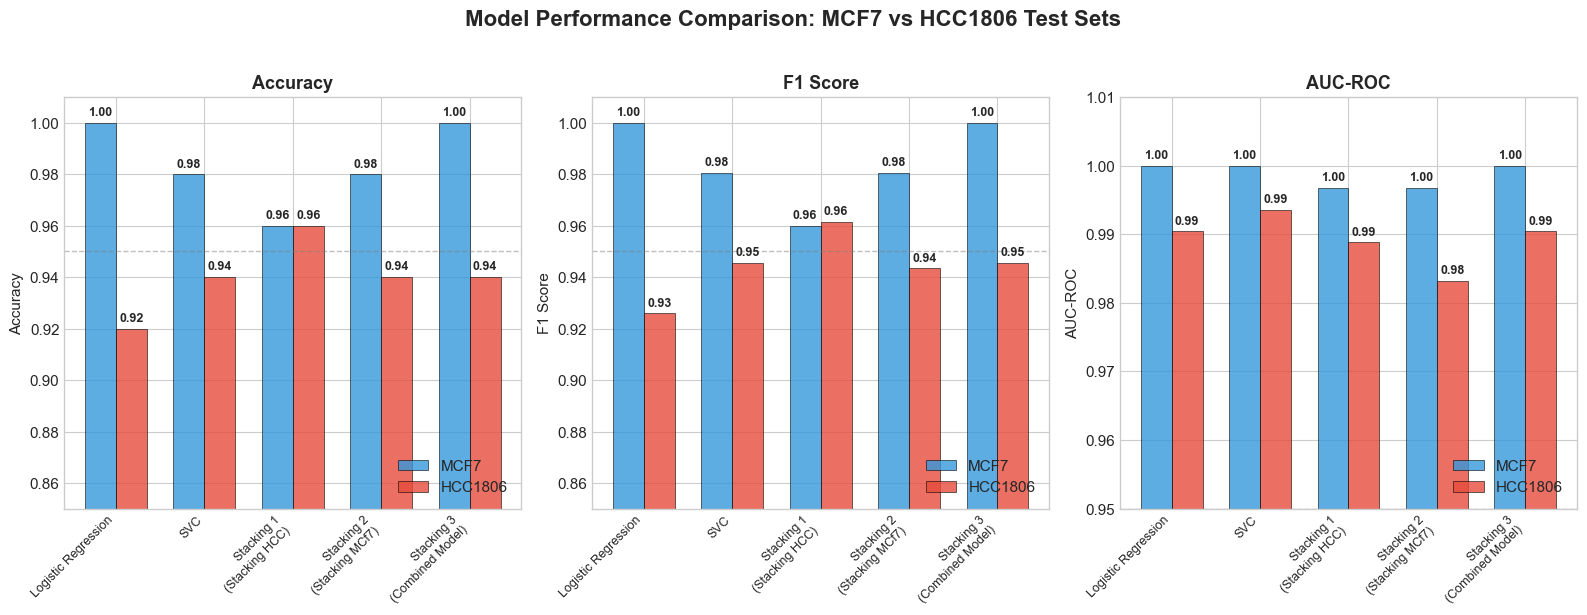

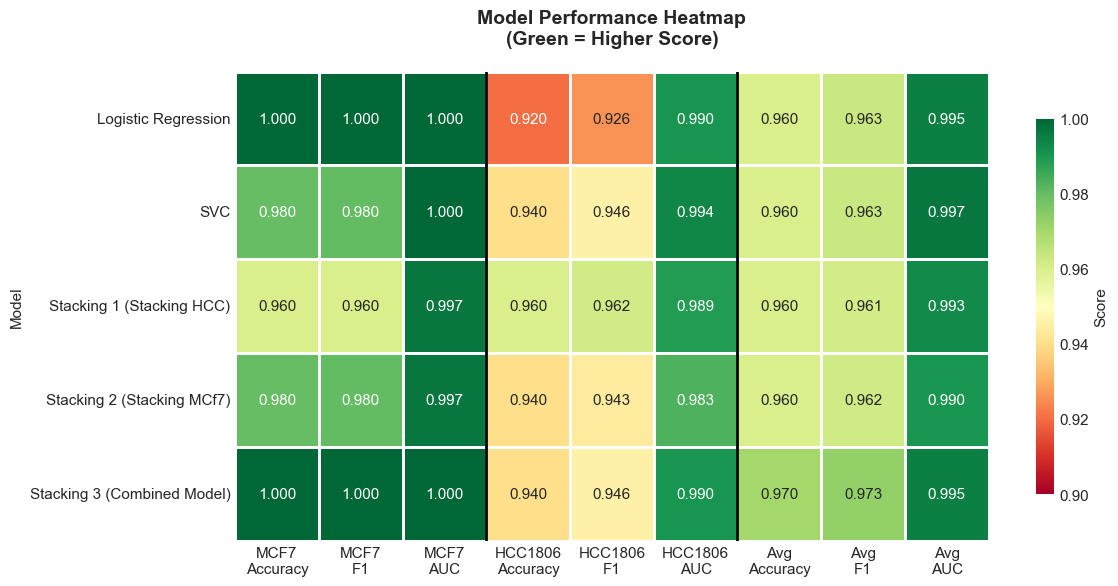

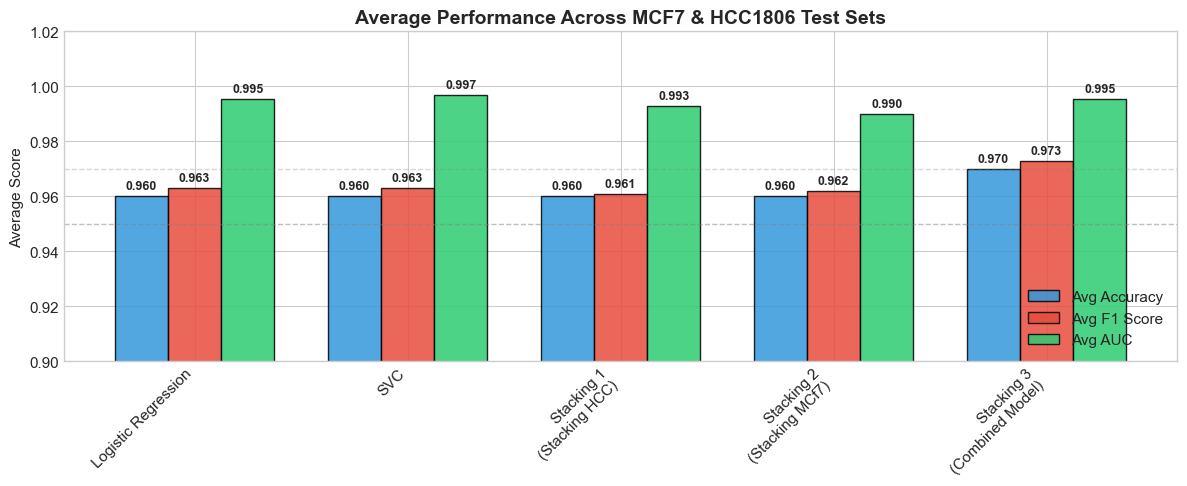

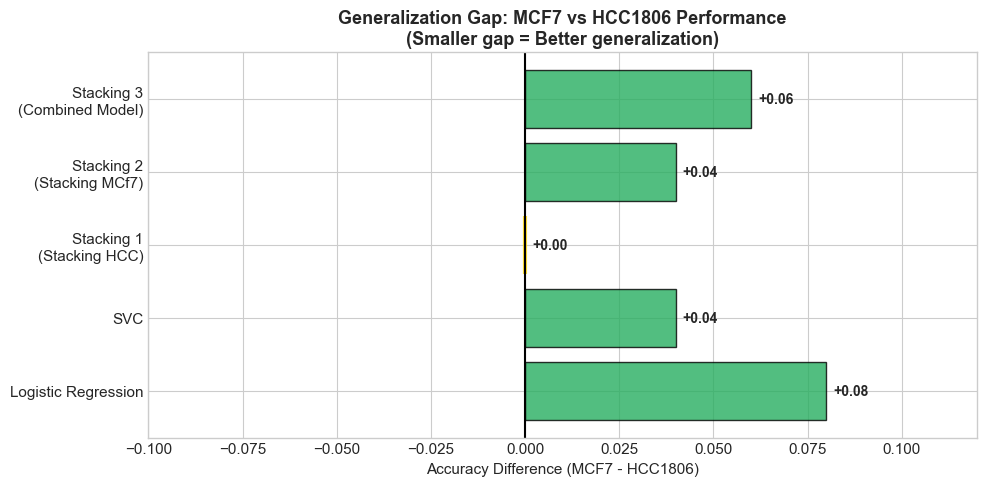


PLOTS SAVED:
  1. model_comparison_grouped_bars.png - Side-by-side comparison by metric
  2. model_comparison_heatmap.png      - Full results heatmap
  3. model_comparison_average.png      - Average performance comparison
  4. model_comparison_gap.png          - Generalization gap analysis


In [35]:
# =============================================================================
# COMPREHENSIVE VISUALIZATION OF ALL MODEL RESULTS
# =============================================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

# =============================================================================
# DATA: All model results
# =============================================================================

results_data = {
    'Model': [
        'Logistic Regression',
        'SVC',
        'Stacking 1\n(Stacking HCC)',
        'Stacking 2\n(Stacking MCf7)',
        'Stacking 3\n(Combined Model)'
    ],
    'MCF7_Accuracy': [1.00, 0.98, 0.96, 0.98, 1.00],
    'MCF7_F1': [1.0000, 0.9804, 0.9600, 0.9804, 1.0000],
    'MCF7_AUC': [1.0, 1.0, 0.9968, 0.9968, 1.0],
    'HCC1806_Accuracy': [0.92, 0.94, 0.96, 0.94, 0.94],
    'HCC1806_F1': [0.9259, 0.9455, 0.9615, 0.9434, 0.9455],
    'HCC1806_AUC': [0.9904, 0.9936, 0.9888, 0.9832, 0.9904]
}

df_results = pd.DataFrame(results_data)

# Calculate averages
df_results['Avg_Accuracy'] = (df_results['MCF7_Accuracy'] + df_results['HCC1806_Accuracy']) / 2
df_results['Avg_F1'] = (df_results['MCF7_F1'] + df_results['HCC1806_F1']) / 2
df_results['Avg_AUC'] = (df_results['MCF7_AUC'] + df_results['HCC1806_AUC']) / 2

# Colors
colors_mcf7 = '#3498db'      # Blue
colors_hcc1806 = '#e74c3c'   # Red
colors_avg = '#2ecc71'       # Green

# =============================================================================
# FIGURE 1: Grouped Bar Charts by Metric
# =============================================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('Model Performance Comparison: MCF7 vs HCC1806 Test Sets', fontsize=16, fontweight='bold', y=1.02)

x = np.arange(len(df_results))
width = 0.35

metrics = [
    ('Accuracy', 'MCF7_Accuracy', 'HCC1806_Accuracy', (0.85, 1.01)),
    ('F1 Score', 'MCF7_F1', 'HCC1806_F1', (0.85, 1.01)),
    ('AUC-ROC', 'MCF7_AUC', 'HCC1806_AUC', (0.95, 1.01))
]

for ax, (metric_name, mcf7_col, hcc_col, ylim) in zip(axes, metrics):
    bars1 = ax.bar(x - width/2, df_results[mcf7_col], width, label='MCF7', color=colors_mcf7, alpha=0.8, edgecolor='black', linewidth=0.5)
    bars2 = ax.bar(x + width/2, df_results[hcc_col], width, label='HCC1806', color=colors_hcc1806, alpha=0.8, edgecolor='black', linewidth=0.5)
    
    # Add value labels on bars
    for bar in bars1:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=9, fontweight='bold')
    for bar in bars2:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    ax.set_ylabel(metric_name)
    ax.set_title(metric_name, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(df_results['Model'], rotation=45, ha='right', fontsize=9)
    ax.set_ylim(ylim)
    ax.legend(loc='lower right')
    ax.axhline(y=0.95, color='gray', linestyle='--', alpha=0.5, linewidth=1)

plt.tight_layout()
plt.savefig('model_comparison_grouped_bars.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# =============================================================================
# FIGURE 2: Heatmap of All Results
# =============================================================================

fig, ax = plt.subplots(figsize=(12, 6))

# Prepare heatmap data
heatmap_data = df_results[['MCF7_Accuracy', 'MCF7_F1', 'MCF7_AUC', 
                            'HCC1806_Accuracy', 'HCC1806_F1', 'HCC1806_AUC',
                            'Avg_Accuracy', 'Avg_F1', 'Avg_AUC']].copy()
heatmap_data.index = df_results['Model'].str.replace('\n', ' ')
heatmap_data.columns = ['MCF7\nAccuracy', 'MCF7\nF1', 'MCF7\nAUC', 
                        'HCC1806\nAccuracy', 'HCC1806\nF1', 'HCC1806\nAUC',
                        'Avg\nAccuracy', 'Avg\nF1', 'Avg\nAUC']

# Create heatmap
sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='RdYlGn', 
            vmin=0.90, vmax=1.0, center=0.95,
            linewidths=1, linecolor='white',
            cbar_kws={'label': 'Score', 'shrink': 0.8},
            ax=ax)

ax.set_title('Model Performance Heatmap\n(Green = Higher Score)', fontsize=14, fontweight='bold', pad=20)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

# Add vertical lines to separate sections
ax.axvline(x=3, color='black', linewidth=2)
ax.axvline(x=6, color='black', linewidth=2)

plt.tight_layout()
plt.savefig('model_comparison_heatmap.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# =============================================================================
# FIGURE 3: Average Performance Comparison (Radar/Spider Chart Alternative - Bar)
# =============================================================================

fig, ax = plt.subplots(figsize=(12, 5))

x = np.arange(len(df_results))
width = 0.25

bars1 = ax.bar(x - width, df_results['Avg_Accuracy'], width, label='Avg Accuracy', color='#3498db', alpha=0.85, edgecolor='black')
bars2 = ax.bar(x, df_results['Avg_F1'], width, label='Avg F1 Score', color='#e74c3c', alpha=0.85, edgecolor='black')
bars3 = ax.bar(x + width, df_results['Avg_AUC'], width, label='Avg AUC', color='#2ecc71', alpha=0.85, edgecolor='black')

# Add value labels
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_ylabel('Average Score')
ax.set_title('Average Performance Across MCF7 & HCC1806 Test Sets', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(df_results['Model'], rotation=45, ha='right')
ax.set_ylim(0.90, 1.02)
ax.legend(loc='lower right')
ax.axhline(y=0.95, color='gray', linestyle='--', alpha=0.5, linewidth=1)
ax.axhline(y=0.97, color='gray', linestyle='--', alpha=0.3, linewidth=1)

plt.tight_layout()
plt.savefig('model_comparison_average.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# =============================================================================
# FIGURE 4: MCF7 vs HCC1806 Performance Gap
# =============================================================================

fig, ax = plt.subplots(figsize=(10, 5))

# Calculate gaps
gaps = df_results['MCF7_Accuracy'] - df_results['HCC1806_Accuracy']
colors_gap = ['#27ae60' if g >= 0 else '#c0392b' for g in gaps]

bars = ax.barh(df_results['Model'], gaps, color=colors_gap, alpha=0.8, edgecolor='black')

for i, (bar, gap) in enumerate(zip(bars, gaps)):
    ax.annotate(f'{gap:+.2f}',
                xy=(gap, bar.get_y() + bar.get_height()/2),
                xytext=(5 if gap >= 0 else -5, 0), 
                textcoords="offset points",
                ha='left' if gap >= 0 else 'right', 
                va='center', fontsize=10, fontweight='bold')

ax.axvline(x=0, color='black', linewidth=1.5)
ax.set_xlabel('Accuracy Difference (MCF7 - HCC1806)')
ax.set_title('Generalization Gap: MCF7 vs HCC1806 Performance\n(Smaller gap = Better generalization)', fontsize=13, fontweight='bold')
ax.set_xlim(-0.1, 0.12)

# Highlight best generalizer
min_gap_idx = np.argmin(np.abs(gaps))
ax.get_children()[min_gap_idx].set_edgecolor('gold')
ax.get_children()[min_gap_idx].set_linewidth(3)

plt.tight_layout()
plt.savefig('model_comparison_gap.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print("\n" + "=" * 70)
print("PLOTS SAVED:")
print("=" * 70)
print("  1. model_comparison_grouped_bars.png - Side-by-side comparison by metric")
print("  2. model_comparison_heatmap.png      - Full results heatmap")
print("  3. model_comparison_average.png      - Average performance comparison")
print("  4. model_comparison_gap.png          - Generalization gap analysis")

## A.6 Cell-Line-Specific Stacking Models as Baselines

As a reference benchmark, the two stacking classifiers originally developed in the **individual cell-line studies** (one tuned on MCF7, one on HCC1806) are evaluated here on the same combined train/test split.

These models were tuned on their full respective datasets with different held-out test splits, so this comparison may carry **slight bias** (potential data leakage since some of the current test samples may have been in the original training data). Nevertheless, they serve as a useful reference for the pooled model's performance.

The two baselines are:
1. **Stacking 1** (SVC + XGBoost + CatBoost &rarr; Logistic Regression): the best model from one of the individual cell-line studies.
2. **Stacking 2** (LR + SVC + XGBoost + CatBoost &rarr; Random Forest): the best model from the other study.

Both are trained here on the **full 20,501 features** with **no scaling and no feature selection** on the combined dataset, then tested on the same test set used as above

In [30]:
# =============================================================================
# STACKING CLASSIFIERS FROM INDIVIDUAL CELL LINE STUDIES
# No scaling, No feature selection (using full 20501 features)
# =============================================================================

from sklearn.ensemble import StackingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
import xgboost as xgb
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix

# -----------------------------------------------------------------------------
# Stacking Classifier 1 (SVC + XGBoost + CatBoost -> LR)
# -----------------------------------------------------------------------------
stacking_clf_1 = StackingClassifier(
    estimators=[
        ('svc', SVC(probability=True, C=6.8471512297826544, gamma=0.0024146208764020648, random_state=42)),
        ('xgboost', xgb.XGBClassifier(
            max_depth=2, 
            learning_rate=0.4,  
            n_estimators=600, 
            objective='binary:logistic',
            tree_method='hist',
            device='cuda',
            verbosity=1,
            random_state=42
        )),
        ('cbc', CatBoostClassifier(
            iterations=622,
            learning_rate=0.4,
            eval_metric='Accuracy',
            task_type='CPU',
            verbose=100,
            random_state=42
        ))
    ],
    final_estimator=LogisticRegression(penalty='l2', max_iter=1000, random_state=42),
    cv=5,
    n_jobs=-1
)

# -----------------------------------------------------------------------------
# Stacking Classifier 2 (LR + SVC + XGBoost + CatBoost -> RF)
# -----------------------------------------------------------------------------
stacking_clf_2 = StackingClassifier(
    estimators=[
        ('lr', LogisticRegression(penalty='l2', random_state=42, solver='lbfgs', max_iter=1000)),
        ('svc', SVC(probability=True, C=10.221318114682536, gamma=0.003404312457253224, random_state=42)),
        ('xgboost', xgb.XGBClassifier(
            max_depth=2, 
            learning_rate=0.4,  
            n_estimators=600, 
            objective='binary:logistic',
            tree_method='hist',
            device='cuda',
            verbosity=1,
            random_state=42
        )),
        ('cbc', CatBoostClassifier(
            iterations=598,
            learning_rate=0.4,
            eval_metric='Accuracy',
            task_type='CPU',
            verbose=100,
            random_state=42
        ))
    ],
    final_estimator=RandomForestClassifier(n_estimators=100, random_state=42),
    cv=5,
    n_jobs=-1
)

# =============================================================================
# TRAIN AND EVALUATE (No scaling, No feature selection)
# =============================================================================

print("=" * 70)
print("TRAINING ON RAW DATA (No Scaling, No Feature Selection)")
print(f"Training samples: {X_combined_train.shape[0]}, Features: {X_combined_train.shape[1]}")
print("=" * 70)

def evaluate_and_report(model, X_test, y_test, dataset_name):
    """Evaluate model and return metrics dict."""
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    
    return {'accuracy': acc, 'f1': f1, 'auc': auc, 'y_pred': y_pred}

# -----------------------------------------------------------------------------
# Train and evaluate Stacking Classifier 1
# -----------------------------------------------------------------------------
print("\n" + "-" * 70)
print("STACKING CLASSIFIER 1: SVC + XGBoost + CatBoost -> LogisticRegression")
print("-" * 70)

print("\nTraining...")
stacking_clf_1.fit(X_combined_train, y_combined_train)
print("Training complete!")

res1_mcf7 = evaluate_and_report(stacking_clf_1, X_mcf7_test, y_mcf7_test, "MCF7")
res1_hcc1806 = evaluate_and_report(stacking_clf_1, X_hcc1806_test, y_hcc1806_test, "HCC1806")

print(f"\n  MCF7 Test:    Accuracy={res1_mcf7['accuracy']:.4f}, F1={res1_mcf7['f1']:.4f}, AUC={res1_mcf7['auc']:.4f}")
print(f"  HCC1806 Test: Accuracy={res1_hcc1806['accuracy']:.4f}, F1={res1_hcc1806['f1']:.4f}, AUC={res1_hcc1806['auc']:.4f}")

# -----------------------------------------------------------------------------
# Train and evaluate Stacking Classifier 2
# -----------------------------------------------------------------------------
print("\n" + "-" * 70)
print("STACKING CLASSIFIER 2: LR + SVC + XGBoost + CatBoost -> RandomForest")
print("-" * 70)

print("\nTraining...")
stacking_clf_2.fit(X_combined_train, y_combined_train)
print("Training complete!")

res2_mcf7 = evaluate_and_report(stacking_clf_2, X_mcf7_test, y_mcf7_test, "MCF7")
res2_hcc1806 = evaluate_and_report(stacking_clf_2, X_hcc1806_test, y_hcc1806_test, "HCC1806")

print(f"\n  MCF7 Test:    Accuracy={res2_mcf7['accuracy']:.4f}, F1={res2_mcf7['f1']:.4f}, AUC={res2_mcf7['auc']:.4f}")
print(f"  HCC1806 Test: Accuracy={res2_hcc1806['accuracy']:.4f}, F1={res2_hcc1806['f1']:.4f}, AUC={res2_hcc1806['auc']:.4f}")

# -----------------------------------------------------------------------------
# Summary Table
# -----------------------------------------------------------------------------
print("\n" + "=" * 70)
print("SUMMARY COMPARISON")
print("=" * 70)

summary_data = [
    ['Stacking 1 (SVC+XGB+CBC->LR)', res1_mcf7['accuracy'], res1_mcf7['f1'], res1_mcf7['auc'],
     res1_hcc1806['accuracy'], res1_hcc1806['f1'], res1_hcc1806['auc']],
    ['Stacking 2 (LR+SVC+XGB+CBC->RF)', res2_mcf7['accuracy'], res2_mcf7['f1'], res2_mcf7['auc'],
     res2_hcc1806['accuracy'], res2_hcc1806['f1'], res2_hcc1806['auc']],
]

summary_df = pd.DataFrame(summary_data, columns=[
    'Model', 'MCF7 Acc', 'MCF7 F1', 'MCF7 AUC', 'HCC1806 Acc', 'HCC1806 F1', 'HCC1806 AUC'
])
print("\n")
print(summary_df.round(4).to_string(index=False))

TRAINING ON RAW DATA (No Scaling, No Feature Selection)
Training samples: 526, Features: 20501

----------------------------------------------------------------------
STACKING CLASSIFIER 1: SVC + XGBoost + CatBoost -> LogisticRegression
----------------------------------------------------------------------

Training...
Training complete!

  MCF7 Test:    Accuracy=0.9600, F1=0.9600, AUC=0.9968
  HCC1806 Test: Accuracy=0.9600, F1=0.9615, AUC=0.9888

----------------------------------------------------------------------
STACKING CLASSIFIER 2: LR + SVC + XGBoost + CatBoost -> RandomForest
----------------------------------------------------------------------

Training...
Training complete!

  MCF7 Test:    Accuracy=0.9800, F1=0.9804, AUC=0.9968
  HCC1806 Test: Accuracy=0.9400, F1=0.9434, AUC=0.9832

SUMMARY COMPARISON


                          Model  MCF7 Acc  MCF7 F1  MCF7 AUC  HCC1806 Acc  HCC1806 F1  HCC1806 AUC
   Stacking 1 (SVC+XGB+CBC->LR)      0.96   0.9600    0.9968         0.96

96 accuracy so it's not bad in it's own. However unlike the Second optuna search model it takes many more features with no scaling at all...

---
# Part B: Binning-Based Model for Cross-Dataset Generalization
---

## B.1 Motivation & Experimental Design

### Why Binning?

When gene expression data comes from different experimental batches or platforms, the **absolute expression values** can shift significantly due to technical factors (sequencing depth, library preparation, etc.), even if the **relative ordering** of genes within a sample is preserved. Binning (discretizing each gene's expression into quantile-based ranks) removes the dependency on absolute scale and retains only the rank structure, which should be more robust to batch effects.

### Experimental Design

The validation strategy is **Leave-One-Dataset-Out (LODO)**:
1. **Train on MCF7 -> Evaluate on HCC1806**: the model never sees HCC1806 during training.
2. **Train on HCC1806 -> Evaluate on MCF7**: the model never sees MCF7 during training.
3. The **final LODO score** is the average accuracy of both directions.

This LODO score is used directly as the Optuna objective function, encouraging selection of configurations that transfer well across cell lines.

The experiments proceed in three stages:
1. **Raw cross-dataset transfer** (no binning) to establish baselines.
2. **Binning + LODO Optuna sweep** to find the best bin count, feature count, and model configuration.
3. **Combined pooled model with binning** to see if binning also helps the within-dataset pooled model.


## B.2 Raw Cross-Dataset Transfer (No Binning Baseline)

Before introducing binning, we first measure how well the **cell-line-specific stacking classifiers**  transfer to the *other* cell line when trained on raw expression values. This establishes the baseline that the binning model must beat to justify the additional preprocessing complexity.

The cells below:
1. Load the aligned (but un-binned) MCF7 and HCC1806 data.
2. Train each cell-line-specific stacking model on one dataset.
3. Evaluate on the other dataset.
4. Report per-direction and average LODO accuracy.

### Cross-dataset evaluation: MCF7 -> HCC1806 and HCC1806 -> MCF7 (no binning)

In [10]:
df_t

,"""output.STAR.PCRPlate1A10_Normoxia_S123_Aligned.sortedByCoord.out.bam""","""output.STAR.PCRPlate1A12_Normoxia_S26_Aligned.sortedByCoord.out.bam""","""output.STAR.PCRPlate1A1_Hypoxia_S97_Aligned.sortedByCoord.out.bam""","""output.STAR.PCRPlate1A2_Hypoxia_S104_Aligned.sortedByCoord.out.bam""","""output.STAR.PCRPlate1A3_Hypoxia_S4_Aligned.sortedByCoord.out.bam""","""output.STAR.PCRPlate1A4_Hypoxia_S8_Aligned.sortedByCoord.out.bam""","""output.STAR.PCRPlate1A5_Hypoxia_S108_Aligned.sortedByCoord.out.bam""","""output.STAR.PCRPlate1A6_Hypoxia_S11_Aligned.sortedByCoord.out.bam""","""output.STAR.PCRPlate1A7_Normoxia_S113_Aligned.sortedByCoord.out.bam""","""output.STAR.PCRPlate1A8_Normoxia_S119_Aligned.sortedByCoord.out.bam""",...,"""output.STAR.PCRPlate4G1_Hypoxia_S193_Aligned.sortedByCoord.out.bam""","""output.STAR.PCRPlate4G2_Hypoxia_S198_Aligned.sortedByCoord.out.bam""","""output.STAR.PCRPlate4G6_Hypoxia_S232_Aligned.sortedByCoord.out.bam""","""output.STAR.PCRPlate4G7_Normoxia_S204_Aligned.sortedByCoord.out.bam""","""output.STAR.PCRPlate4H10_Normoxia_S210_Aligned.sortedByCoord.out.bam""","""output.STAR.PCRPlate4H11_Normoxia_S214_Aligned.sortedByCoord.out.bam""","""output.STAR.PCRPlate4H2_Hypoxia_S199_Aligned.sortedByCoord.out.bam""","""output.STAR.PCRPlate4H7_Normoxia_S205_Aligned.sortedByCoord.out.bam""","""output.STAR.PCRPlate4H9_Normoxia_S236_Aligned.sortedByCoord.out.bam""",PERC_NONZERO_VALUES
A1BG,81.000000,35.00000,9.000000,466.000000,17.000000,20.000000,94.000000,74.000000,58.000000,33.000000,...,32.000000,104.000000,10.000000,3.000000,53.000000,7.000000,49.000000,11.000000,73.00000,934.156379
A1BG-AS1,0.000000,76.00000,20.000000,139.000000,66.000000,21.000000,340.000000,173.000000,0.000000,43.000000,...,126.000000,128.000000,52.000000,37.000000,111.000000,34.000000,69.000000,33.000000,139.00000,831.275720
A1CF,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,16.460905
A2M,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,12.345679
A2M-AS1,0.000000,0.00000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,49.382716
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZYX,81.000000,124.00000,51.000000,134.000000,15.000000,22.000000,97.000000,73.000000,30.000000,68.000000,...,63.000000,39.000000,42.000000,27.000000,156.000000,49.000000,178.000000,35.000000,33.00000,893.004115
ZZEF1,67.000000,0.00000,5.000000,0.000000,0.000000,0.000000,0.000000,123.000000,70.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,70.00000,518.518519
ZZZ3,131.000000,129.00000,2.000000,5.000000,37.000000,29.000000,200.000000,48.000000,4.000000,77.000000,...,160.000000,9.000000,14.000000,57.000000,182.000000,19.000000,144.000000,15.000000,85.00000,893.004115
PERC_NONZERO_VALUES,461.446401,480.89417,422.593606,324.713626,433.236451,346.512224,398.016755,461.959309,401.350658,361.771243,...,461.873825,422.935545,448.409985,442.853479,531.800308,473.627971,462.942383,444.947854,514.74611,1000.000000


In [27]:
from sklearn.ensemble import StackingClassifier, RandomForestClassifier
feature_cols = [col for col in df_mcf7_aligned.columns if col not in ['LABEL']]

# Training data: MCF7 (entire aligned dataset)
X_train = df_mcf7_aligned[feature_cols].values
Y_train = df_mcf7_aligned['LABEL'].values

# Test data: HCC1806 (entire aligned dataset)
X_test = df_hcc1806_aligned[feature_cols].values
Y_test = df_hcc1806_aligned['LABEL'].values

print(f"Training set (MCF7): X_train shape = {X_train.shape}, Y_train shape = {Y_train.shape}")
print(f"Test set (HCC1806): X_test shape = {X_test.shape}, Y_test shape = {Y_test.shape}")
print(f"\nTraining label distribution: 0 (Normoxia) = {sum(Y_train == 0)}, 1 (Hypoxia) = {sum(Y_train == 1)}")
print(f"Test label distribution: 0 (Normoxia) = {sum(Y_test == 0)}, 1 (Hypoxia) = {sum(Y_test == 1)}")

Training set (MCF7): X_train shape = (383, 20501), Y_train shape = (383,)
Test set (HCC1806): X_test shape = (243, 20501), Y_test shape = (243,)

Training label distribution: 0 (Normoxia) = 192, 1 (Hypoxia) = 191
Test label distribution: 0 (Normoxia) = 117, 1 (Hypoxia) = 126


MCF7 -> HCC

TRAINING MCF7 MODEL ON FULL MCF7 DATASET
[LibSVM][18:23:59] INFO: C:\actions-runner\_work\xgboost\xgboost\src\data\iterative_dmatrix.cc:56: Finished constructing the `IterativeDMatrix`: (383, 20501, 7851883).
[18:23:59] INFO: C:\actions-runner\_work\xgboost\xgboost\src\data\ellpack_page.cu:167: Ellpack is dense.
0:	learn: 0.9712794	total: 344ms	remaining: 3m 33s
100:	learn: 1.0000000	total: 22.1s	remaining: 1m 54s
200:	learn: 1.0000000	total: 41.9s	remaining: 1m 27s
300:	learn: 1.0000000	total: 1m 2s	remaining: 1m 6s
400:	learn: 1.0000000	total: 1m 22s	remaining: 45.4s
500:	learn: 1.0000000	total: 1m 42s	remaining: 24.7s
600:	learn: 1.0000000	total: 2m 1s	remaining: 4.24s
621:	learn: 1.0000000	total: 2m 5s	remaining: 0us
[LibSVM][LibSVM][LibSVM][LibSVM][LibSVM]

[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:  5.4min finished


[18:31:31] INFO: C:\actions-runner\_work\xgboost\xgboost\src\data\iterative_dmatrix.cc:56: Finished constructing the `IterativeDMatrix`: (306, 20501, 6273306).
[18:31:31] INFO: C:\actions-runner\_work\xgboost\xgboost\src\data\ellpack_page.cu:167: Ellpack is dense.
[18:31:33] INFO: C:\actions-runner\_work\xgboost\xgboost\src\data\iterative_dmatrix.cc:56: Finished constructing the `IterativeDMatrix`: (306, 20501, 6273306).
[18:31:33] INFO: C:\actions-runner\_work\xgboost\xgboost\src\data\ellpack_page.cu:167: Ellpack is dense.
[18:31:34] INFO: C:\actions-runner\_work\xgboost\xgboost\src\data\iterative_dmatrix.cc:56: Finished constructing the `IterativeDMatrix`: (306, 20501, 6273306).
[18:31:34] INFO: C:\actions-runner\_work\xgboost\xgboost\src\data\ellpack_page.cu:167: Ellpack is dense.
[18:31:35] INFO: C:\actions-runner\_work\xgboost\xgboost\src\data\iterative_dmatrix.cc:56: Finished constructing the `IterativeDMatrix`: (307, 20501, 6293807).
[18:31:35] INFO: C:\actions-runner\_work\xgbo

[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:    6.3s finished


0:	learn: 0.9705882	total: 174ms	remaining: 1m 47s
100:	learn: 1.0000000	total: 19s	remaining: 1m 37s
200:	learn: 1.0000000	total: 39.2s	remaining: 1m 22s
300:	learn: 1.0000000	total: 59.9s	remaining: 1m 3s
400:	learn: 1.0000000	total: 1m 19s	remaining: 43.9s
500:	learn: 1.0000000	total: 1m 38s	remaining: 23.8s
600:	learn: 1.0000000	total: 1m 57s	remaining: 4.09s
621:	learn: 1.0000000	total: 2m	remaining: 0us
0:	learn: 0.9705882	total: 170ms	remaining: 1m 45s
100:	learn: 1.0000000	total: 18.3s	remaining: 1m 34s
200:	learn: 1.0000000	total: 36.4s	remaining: 1m 16s
300:	learn: 1.0000000	total: 55.8s	remaining: 59.5s
400:	learn: 1.0000000	total: 1m 15s	remaining: 41.5s
500:	learn: 1.0000000	total: 1m 34s	remaining: 22.7s
600:	learn: 1.0000000	total: 1m 52s	remaining: 3.92s
621:	learn: 1.0000000	total: 1m 56s	remaining: 0us
0:	learn: 0.9771242	total: 173ms	remaining: 1m 47s
100:	learn: 1.0000000	total: 17.8s	remaining: 1m 31s
200:	learn: 1.0000000	total: 35.4s	remaining: 1m 14s
300:	learn:

[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:  9.9min finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished



MCF7 MODEL - RESULTS ON HCC DATA (Cross-Dataset Test)
Accuracy:  0.8642
Precision: 0.9429
Recall:    0.7857
F1 Score:  0.8571

Confusion Matrix:
[[111   6]
 [ 27  99]]


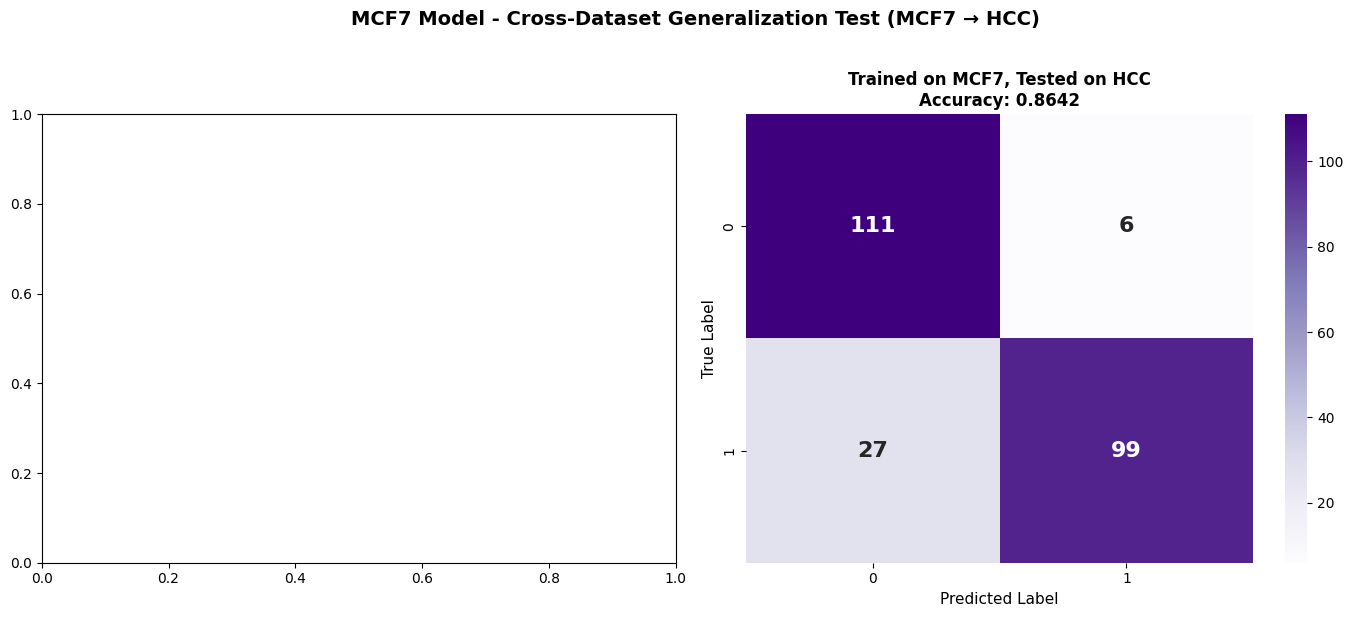


Results saved to 'mcf7_model_cross_dataset_results.csv'


In [25]:
from sklearn.ensemble import StackingClassifier
import xgboost as xgb
from catboost import CatBoostClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# MCF7 Stacking Classifier (best model)
stacking_clf_mcf7 = StackingClassifier(
    estimators=[
        ('svc', SVC(probability=True, C=6.8471512297826544, gamma=0.0024146208764020648, verbose=True)),
        ('xgboost', xgb.XGBClassifier(
            max_depth=2, 
            learning_rate=0.4,  
            n_estimators=600, 
            objective='binary:logistic',
            tree_method='hist',
            device='cuda',
            verbosity=2
        )),
        ('cbc', CatBoostClassifier(
            iterations=622,
            learning_rate=0.4,
            eval_metric='Accuracy',
            task_type='GPU',
            verbose=100
        ))
    ],
    verbose=3,
    final_estimator=LogisticRegression(penalty='l2', verbose=1),
    cv=5
)

# Train on full MCF7 data
print("=" * 60)
print("TRAINING MCF7 MODEL ON FULL MCF7 DATASET")
print("=" * 60)
stacking_clf_mcf7.fit(X_train, Y_train)


# Cross-dataset: Predict on HCC data
y_pred_mcf7_on_hcc = stacking_clf_mcf7.predict(X_test)
accuracy_mcf7_on_hcc = accuracy_score(Y_test, y_pred_mcf7_on_hcc)
precision_mcf7_on_hcc = precision_score(Y_test, y_pred_mcf7_on_hcc)
recall_mcf7_on_hcc = recall_score(Y_test, y_pred_mcf7_on_hcc)
f1_mcf7_on_hcc = f1_score(Y_test, y_pred_mcf7_on_hcc)
cm_mcf7_on_hcc = confusion_matrix(Y_test, y_pred_mcf7_on_hcc)

print("\n" + "=" * 60)
print("MCF7 MODEL - RESULTS ON HCC DATA (Cross-Dataset Test)")
print("=" * 60)
print(f"Accuracy:  {accuracy_mcf7_on_hcc:.4f}")
print(f"Precision: {precision_mcf7_on_hcc:.4f}")
print(f"Recall:    {recall_mcf7_on_hcc:.4f}")
print(f"F1 Score:  {f1_mcf7_on_hcc:.4f}")
print("\nConfusion Matrix:")
print(cm_mcf7_on_hcc)



# Plot both confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('MCF7 Model - Cross-Dataset Generalization Test (MCF7 → HCC)', fontsize=14, fontweight='bold', y=1.02)

# Right: MCF7 on HCC (cross-dataset)
sns.heatmap(cm_mcf7_on_hcc, annot=True, fmt='d', cmap='Purples', ax=axes[1],
            annot_kws={'size': 16, 'fontweight': 'bold'})
axes[1].set_title(f'Trained on MCF7, Tested on HCC\nAccuracy: {accuracy_mcf7_on_hcc:.4f}', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted Label', fontsize=11)
axes[1].set_ylabel('True Label', fontsize=11)

plt.tight_layout()
plt.savefig('mcf7_model_cross_dataset_test.png', dpi=300, bbox_inches='tight')
plt.show()

# Save results
results_df_mcf7 = pd.DataFrame([
    {'Model': 'MCF7 Stacking', 'Train Data': 'MCF7', 'Test Data': 'HCC', 
     'Accuracy': accuracy_mcf7_on_hcc, 'Precision': precision_mcf7_on_hcc, 
     'Recall': recall_mcf7_on_hcc, 'F1 Score': f1_mcf7_on_hcc}
])
results_df_mcf7.to_csv('mcf7_model_cross_dataset_results.csv', index=False)
print("\nResults saved to 'mcf7_model_cross_dataset_results.csv'")

HCC -> MCF7 (Ignore the text on the diagram I forgot to change it from the previous one - will fix)

TRAINING HCC MODEL ON FULL HCC DATASET


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    1.8s finished


[LibSVM][21:13:15] INFO: C:\actions-runner\_work\xgboost\xgboost\src\data\iterative_dmatrix.cc:56: Finished constructing the `IterativeDMatrix`: (243, 20501, 4981743).
[21:13:15] INFO: C:\actions-runner\_work\xgboost\xgboost\src\data\ellpack_page.cu:167: Ellpack is dense.
0:	learn: 0.9547325	total: 211ms	remaining: 2m 5s
100:	learn: 1.0000000	total: 21.4s	remaining: 1m 45s
200:	learn: 1.0000000	total: 42.5s	remaining: 1m 23s
300:	learn: 1.0000000	total: 1m 3s	remaining: 1m 2s
400:	learn: 1.0000000	total: 1m 24s	remaining: 41.7s
500:	learn: 1.0000000	total: 1m 45s	remaining: 20.5s
597:	learn: 1.0000000	total: 2m 6s	remaining: 0us


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    1.2s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    1.1s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.4s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.7s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.6s finished
[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:    4.6s finished


[LibSVM][LibSVM][LibSVM][LibSVM][LibSVM]

...

[21:17:13] INFO: C:\actions-runner\_work\xgboost\xgboost\src\data\iterative_dmatrix.cc:56: Finished constructing the `IterativeDMatrix`: (194, 20501, 3977194).
[21:17:13] INFO: C:\actions-runner\_work\xgboost\xgboost\src\data\ellpack_page.cu:167: Ellpack is dense.
[21:17:14] INFO: C:\actions-runner\_work\xgboost\xgboost\src\data\iterative_dmatrix.cc:56: Finished constructing the `IterativeDMatrix`: (194, 20501, 3977194).
[21:17:14] INFO: C:\actions-runner\_work\xgboost\xgboost\src\data\ellpack_page.cu:167: Ellpack is dense.
[21:17:15] INFO: C:\actions-runner\_work\xgboost\xgboost\src\data\iterative_dmatrix.cc:56: Finished constructing the `IterativeDMatrix`: (194, 20501, 3977194).
[21:17:15] INFO: C:\actions-runner\_work\xgboost\xgboost\src\data\ellpack_page.cu:167: Ellpack is dense.
[21:17:17] INFO: C:\actions-runner\_work\xgboost\xgboost\src\data\iterative_dmatrix.cc:56: Finished constructing the `IterativeDMatrix`: (195, 20501, 3997695).
[21:17:17] INFO: C:\actions-runner\_work\xgbo

[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:    5.6s finished


0:	learn: 0.9587629	total: 204ms	remaining: 2m 1s
100:	learn: 1.0000000	total: 20.6s	remaining: 1m 41s
200:	learn: 1.0000000	total: 41s	remaining: 1m 20s
300:	learn: 1.0000000	total: 1m 1s	remaining: 1m
400:	learn: 1.0000000	total: 1m 21s	remaining: 39.8s
500:	learn: 1.0000000	total: 1m 41s	remaining: 19.6s
597:	learn: 1.0000000	total: 2m	remaining: 0us
0:	learn: 0.9690722	total: 201ms	remaining: 1m 59s
100:	learn: 1.0000000	total: 20.6s	remaining: 1m 41s
200:	learn: 1.0000000	total: 41.3s	remaining: 1m 21s
300:	learn: 1.0000000	total: 1m 1s	remaining: 1m
400:	learn: 1.0000000	total: 1m 22s	remaining: 40.5s
500:	learn: 1.0000000	total: 1m 43s	remaining: 20s
597:	learn: 1.0000000	total: 2m 3s	remaining: 0us
0:	learn: 0.9587629	total: 201ms	remaining: 2m
100:	learn: 1.0000000	total: 21.2s	remaining: 1m 44s
200:	learn: 1.0000000	total: 42.2s	remaining: 1m 23s
300:	learn: 1.0000000	total: 1m 3s	remaining: 1m 2s
400:	learn: 1.0000000	total: 1m 24s	remaining: 41.4s
500:	learn: 1.0000000	tota

[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed: 10.6min finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.0s finished



MCF7 MODEL - RESULTS ON HCC DATA (Cross-Dataset Test)
Accuracy:  0.8982
Precision: 0.8585
Recall:    0.9529
F1 Score:  0.9032

Confusion Matrix:
[[162  30]
 [  9 182]]


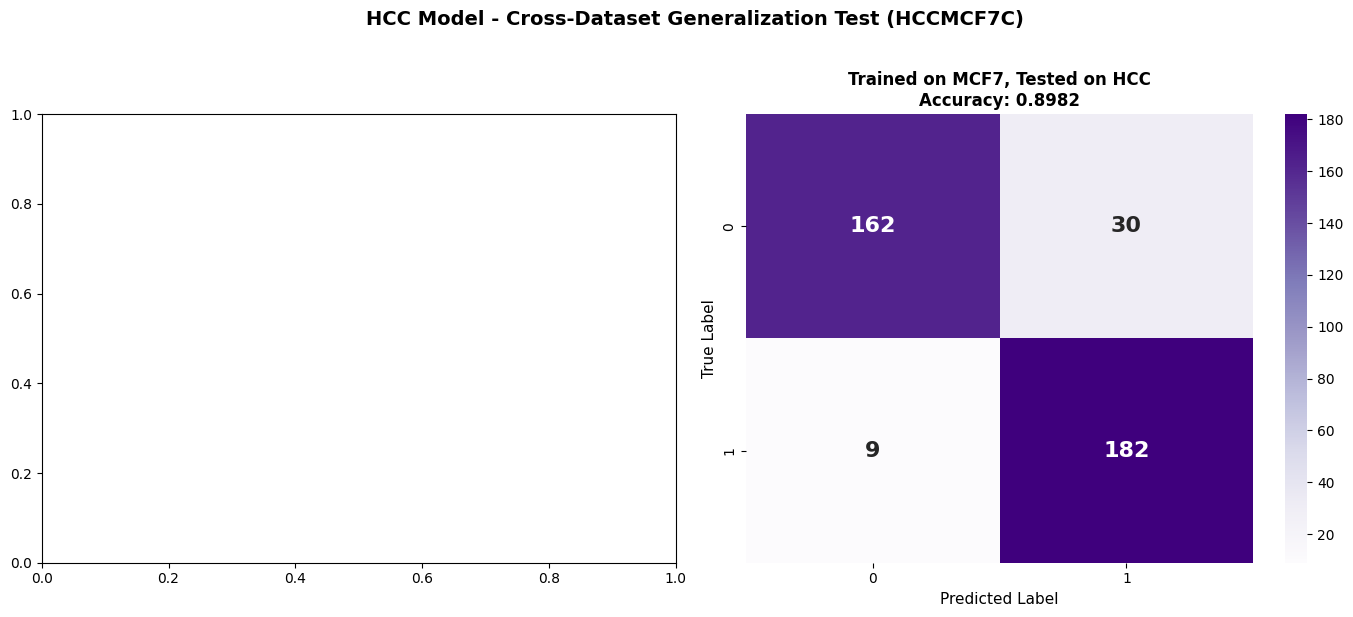


Results saved to 'mcf7_model_cross_dataset_results.csv'


In [28]:
from sklearn.ensemble import StackingClassifier
import xgboost as xgb
from catboost import CatBoostClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# HCC Stacking Classifier (best model)
stacking_clf_mcf7 = StackingClassifier(
    estimators=[
        ('lr', LogisticRegression(penalty='l2', random_state=42, solver='lbfgs', max_iter=1000, verbose=1)),
        ('svc', SVC(probability=True, C=10.221318114682536, gamma=0.003404312457253224, random_state=42, verbose=True)),
        ('xgboost', xgb.XGBClassifier(
            max_depth=2, 
            learning_rate=0.4,  
            n_estimators=600, 
            objective='binary:logistic',
            tree_method='hist',
            device='cuda',
            verbosity=2
        )),
        ('cbc', CatBoostClassifier(
            iterations=598,
            learning_rate=0.4,
            eval_metric='Accuracy',
            task_type='GPU',
            verbose=100
        ))
    ],
    verbose=3,
    final_estimator=RandomForestClassifier(random_state=43, verbose=1),
    cv=5
)

# Train on full MCF7 data
print("=" * 60)
print("TRAINING HCC MODEL ON FULL HCC DATASET")
print("=" * 60)
stacking_clf_mcf7.fit(X_test, Y_test)


# Cross-dataset: Predict on HCC data
y_pred_mcf7_on_hcc = stacking_clf_mcf7.predict(X_train)
accuracy_mcf7_on_hcc = accuracy_score(Y_train, y_pred_mcf7_on_hcc)
precision_mcf7_on_hcc = precision_score(Y_train, y_pred_mcf7_on_hcc)
recall_mcf7_on_hcc = recall_score(Y_train, y_pred_mcf7_on_hcc)
f1_mcf7_on_hcc = f1_score(Y_train, y_pred_mcf7_on_hcc)
cm_mcf7_on_hcc = confusion_matrix(Y_train, y_pred_mcf7_on_hcc)

print("\n" + "=" * 60)
print("MCF7 MODEL - RESULTS ON HCC DATA (Cross-Dataset Test)")
print("=" * 60)
print(f"Accuracy:  {accuracy_mcf7_on_hcc:.4f}")
print(f"Precision: {precision_mcf7_on_hcc:.4f}")
print(f"Recall:    {recall_mcf7_on_hcc:.4f}")
print(f"F1 Score:  {f1_mcf7_on_hcc:.4f}")
print("\nConfusion Matrix:")
print(cm_mcf7_on_hcc)



# Plot both confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('HCC Model - Cross-Dataset Generalization Test (HCCMCF7C)', fontsize=14, fontweight='bold', y=1.02)

# Right: MCF7 on HCC (cross-dataset)
sns.heatmap(cm_mcf7_on_hcc, annot=True, fmt='d', cmap='Purples', ax=axes[1],
            annot_kws={'size': 16, 'fontweight': 'bold'})
axes[1].set_title(f'Trained on MCF7, Tested on HCC\nAccuracy: {accuracy_mcf7_on_hcc:.4f}', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted Label', fontsize=11)
axes[1].set_ylabel('True Label', fontsize=11)

plt.tight_layout()
plt.savefig('mcf7_model_cross_dataset_test.png', dpi=300, bbox_inches='tight')
plt.show()

# Save results
results_df_mcf7 = pd.DataFrame([
    {'Model': 'MCF7 Stacking', 'Train Data': 'MCF7', 'Test Data': 'HCC', 
     'Accuracy': accuracy_mcf7_on_hcc, 'Precision': precision_mcf7_on_hcc, 
     'Recall': recall_mcf7_on_hcc, 'F1 Score': f1_mcf7_on_hcc}
])
results_df_mcf7.to_csv('mcf7_model_cross_dataset_results.csv', index=False)
print("\nResults saved to 'mcf7_model_cross_dataset_results.csv'")

## B.3 Quantile Binning Implementation & LODO Optuna Sweep

### Binning Function

The `bin_expression_quantiles` function below discretizes each gene's expression values into quantile-based bins **independently per sample**. Key design choices:
- Zeros are optionally assigned to bin 0 (since zero-inflation is common in single-cell RNA-seq).
- Non-zero values are ranked into `num_bins` equal-frequency bins using `pd.qcut`.
- The number of bins is a **tunable hyperparameter** (optimized by Optuna alongside the model hyperparameters).

Importantly, binning is applied **before** ANOVA feature selection, so the F-statistics are computed on binned (ordinal) values rather than raw counts. This ensures the selected features are those most discriminative in the binned representation.

In [4]:
import numpy as np
import pandas as pd

def bin_expression_quantiles(
    x: np.ndarray, 
    num_bins: int = 50, 
    zero_as_bin0: bool = True, 
    copy: bool = True
) -> np.ndarray:
    """
    Convert a cell-by-gene expression matrix into a relative/binned representation
    using per-cell quantile binning.
    
    Parameters
    ----------
    x : np.ndarray
        Expression matrix of shape (num_cells, num_genes), float or int.
    num_bins : int
        Number of quantile bins for non-zero values (hyperparameter).
        Output bins will be in range [0, num_bins] where 0 = zero/non-expressed.
    zero_as_bin0 : bool
        If True, original zeros (and NaNs) map to bin 0, non-zero values to [1, num_bins].
        If False, no special treatment for zeros.
    copy : bool
        If True, work on a copy of the input array.
    
    Returns
    -------
    x_binned : np.ndarray
        Integer array of shape (num_cells, num_genes) with bin indices.
        - Bin 0: zeros / non-expressed genes
        - Bins 1 to num_bins: relative expression level within each cell
    
    Notes
    -----
    Binning is PER-CELL (axis=1): quantiles are computed independently for each cell
    across its genes. The bin index is computed as the count of quantile thresholds
    the value is <= to, giving a rank-based relative expression measure.
    
    This approach is useful for cross-dataset generalization as it normalizes
    expression to relative ranks within each cell, reducing batch effects.
    """
    if copy:
        x = x.astype(float).copy()
    else:
        x = x.astype(float)
    
    # Store original zeros/NaNs mask
    if zero_as_bin0:
        zero_mask = (x == 0) | np.isnan(x)
        x[x == 0] = np.nan  # Exclude zeros from quantile computation
    
    # Compute quantile thresholds per cell (axis=1 = across genes)
    qs = np.linspace(0, 1, num_bins)
    
    # np.nanquantile with axis=1 gives shape (num_bins, num_cells)
    # We need to compare each gene value against its cell's quantiles
    quantile_thresholds = np.nanquantile(x, qs, axis=1)  # (num_bins, num_cells)
    
    # Count how many quantile thresholds each value is <= to
    # x has shape (num_cells, num_genes)
    # quantile_thresholds has shape (num_bins, num_cells)
    # We need quantile_thresholds to be (num_bins, num_cells, 1) for broadcasting
    x_binned = (x <= quantile_thresholds[..., None]).sum(axis=0)  # (num_cells, num_genes)
    
    # Convert to integer
    x_binned = x_binned.astype(int)
    
    # Restore zeros to bin 0
    if zero_as_bin0:
        x_binned[zero_mask] = 0
    
    return x_binned


def bin_dataframe(
    df: pd.DataFrame, 
    num_bins: int = 50,
    zero_as_bin0: bool = True
) -> pd.DataFrame:
    """
    Apply quantile binning to a DataFrame, preserving index and column labels.
    
    Parameters
    ----------
    df : pd.DataFrame
        Expression DataFrame with cells as rows, genes as columns.
    num_bins : int
        Number of quantile bins.
    zero_as_bin0 : bool
        If True, zeros map to bin 0.
    
    Returns
    -------
    pd.DataFrame
        Binned expression DataFrame with same index/columns.
    """
    x_binned = bin_expression_quantiles(
        df.values, 
        num_bins=num_bins, 
        zero_as_bin0=zero_as_bin0
    )
    return pd.DataFrame(x_binned, index=df.index, columns=df.columns)


In [31]:
NUM_BINS = 50  # Hyperparameter to tune

# Get feature columns (exclude LABEL, PERC_NONZERO_VALUES)
feature_cols = [col for col in df_mcf7_aligned.columns if col not in ['LABEL', 'PERC_NONZERO_VALUES']]

# Bin the expression data
X_train_binned = bin_expression_quantiles(df_mcf7_aligned[feature_cols].values, num_bins=NUM_BINS)
X_test_binned = bin_expression_quantiles(df_hcc1806_aligned[feature_cols].values, num_bins=NUM_BINS)

print(f"X_train_binned shape: {X_train_binned.shape}, range: [{X_train_binned.min()}, {X_train_binned.max()}]")
print(f"X_test_binned shape: {X_test_binned.shape}, range: [{X_test_binned.min()}, {X_test_binned.max()}]")

X_train_binned shape: (383, 20500), range: [0, 50]
X_test_binned shape: (243, 20500), range: [0, 50]


### LODO Optuna Sweep: Optimizing Binning + Model Hyperparameters

The Optuna objective function below implements the full **Leave-One-Dataset-Out** evaluation:

For each trial:
1. Sample hyperparameters: number of quantile bins, number of ANOVA-selected features, choice of base estimators, and their per-estimator hyperparameters.
2. **Direction 1 (MCF7 -> HCC1806)**: Bin MCF7 training data, select features, train stacking classifier, then bin HCC1806 with the same bin count, apply the same feature mask, and predict.
3. **Direction 2 (HCC1806 -> MCF7)**: Reverse the roles.
4. Return the **average accuracy** across both directions as the trial's score.

This ensures the optimizer favors configurations that generalize across cell lines, not just those that overfit to one.

In [21]:
# =============================================================================
# LODO OBJECTIVE WITH MANDATORY BINNING (num_bins <= n_features)
# =============================================================================

MAX_FEATURES = 1000
MIN_FEATURES = 50

def objective_lodo_binning(trial):
    """
    Optuna objective with LODO validation and mandatory binning.
    
    Constraint: num_bins <= n_features
    When num_bins == n_features → Ranking mode
    """
    
    # ==========================================================================
    # FEATURE AND BINNING HYPERPARAMETERS
    # ==========================================================================
    
    n_features = trial.suggest_int("n_features", MIN_FEATURES, MAX_FEATURES, step=50)
    
    # num_bins MUST be <= n_features
    num_bins = trial.suggest_int("num_bins", MIN_FEATURES, n_features, step=50)
    
    # ==========================================================================
    # MODEL SELECTION HYPERPARAMETERS
    # ==========================================================================
    
    use_lr = trial.suggest_categorical("use_lr", [True, False])
    use_svc = trial.suggest_categorical("use_svc", [True, False])
    use_xgb = trial.suggest_categorical("use_xgb", [True, False])
    use_cbc = trial.suggest_categorical("use_cbc", [True, False])
    
    # Need at least 2 base estimators for stacking - prune invalid trials
    if sum([use_lr, use_svc, use_xgb, use_cbc]) < 2:
        raise optuna.TrialPruned("Need at least 2 base estimators for stacking")
    
    params = {
        "use_lr": use_lr,
        "use_svc": use_svc,
        "use_xgb": use_xgb,
        "use_cbc": use_cbc,
    }
    
    if use_lr:
        params["lr_C"] = trial.suggest_float("lr_C", 0.01, 10.0, log=True)
    
    if use_svc:
        params["svc_C"] = trial.suggest_float("svc_C", 0.1, 100.0, log=True)
        params["svc_gamma"] = trial.suggest_float("svc_gamma", 1e-4, 1e-1, log=True)
    
    if use_xgb:
        params["xgb_depth"] = trial.suggest_int("xgb_depth", 2, 4)
        params["xgb_lr"] = trial.suggest_float("xgb_lr", 0.1, 0.5)
        params["xgb_n_estimators"] = trial.suggest_int("xgb_n_estimators", 100, 600, step=50)
        params["xgb_reg_alpha"] = trial.suggest_float("xgb_reg_alpha", 0.1, 10.0, log=True)
        params["xgb_reg_lambda"] = trial.suggest_float("xgb_reg_lambda", 0.1, 10.0, log=True)
    
    if use_cbc:
        params["cbc_depth"] = trial.suggest_int("cbc_depth", 2, 6)
        params["cbc_lr"] = trial.suggest_float("cbc_lr", 0.1, 0.5)
        params["cbc_iterations"] = trial.suggest_int("cbc_iterations", 100, 600, step=50)
        params["cbc_l2_reg"] = trial.suggest_float("cbc_l2_reg", 1.0, 10.0)
    
    params["final_estimator"] = trial.suggest_categorical("final_estimator", ["lr", "rf"])
    
    # ==========================================================================
    # PREPARE DATA WITH BINNING
    # ==========================================================================
    
    feature_cols = [col for col in df_mcf7_aligned.columns if col not in ["LABEL"]]
    
    X_mcf7_raw = df_mcf7_aligned[feature_cols].values.astype(np.float32)
    y_mcf7 = df_mcf7_aligned["LABEL"].values.astype(np.int32)
    X_hcc1806_raw = df_hcc1806_aligned[feature_cols].values.astype(np.float32)
    y_hcc1806 = df_hcc1806_aligned["LABEL"].values.astype(np.int32)
    
    # Apply binning
    X_mcf7 = bin_expression_quantiles(X_mcf7_raw, num_bins=num_bins).astype(np.float32)
    X_hcc1806 = bin_expression_quantiles(X_hcc1806_raw, num_bins=num_bins).astype(np.float32)
    
    # ==========================================================================
    # LODO VALIDATION
    # ==========================================================================
    
    try:
        # Direction 1: Train on MCF7, Test on HCC1806
        pipeline_1 = Pipeline([
            ("selector", SelectKBest(f_classif, k=n_features)),
            ("stacking", create_stacking_classifier(params))
        ])
        pipeline_1.fit(X_mcf7, y_mcf7)
        score_mcf7_to_hcc = pipeline_1.score(X_hcc1806, y_hcc1806)
        
        # Direction 2: Train on HCC1806, Test on MCF7
        pipeline_2 = Pipeline([
            ("selector", SelectKBest(f_classif, k=n_features)),
            ("stacking", create_stacking_classifier(params))
        ])
        pipeline_2.fit(X_hcc1806, y_hcc1806)
        score_hcc_to_mcf7 = pipeline_2.score(X_mcf7, y_mcf7)
        
        avg_score = (score_mcf7_to_hcc + score_hcc_to_mcf7) / 2
        
        # Log details
        trial.set_user_attr("score_mcf7_to_hcc", score_mcf7_to_hcc)
        trial.set_user_attr("score_hcc_to_mcf7", score_hcc_to_mcf7)
        trial.set_user_attr("is_ranking_mode", num_bins == n_features)
        
        return avg_score
        
    except Exception as e:
        print(f"Trial failed: {e}")
        raise optuna.TrialPruned(f"Trial failed: {e}")

In [13]:
USE_WANDB = False

In [22]:
# =============================================================================
# RUN LODO OPTUNA STUDY
# =============================================================================

def run_lodo_optuna_study(n_trials=100, use_wandb=False):
    """
    Run Optuna hyperparameter optimization with LODO validation and mandatory binning.
    """
    study = optuna.create_study(
        direction="maximize",
        study_name="lodo_binning_stacking",
        sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
    )
    
    callbacks = []
    
    if use_wandb:
        wandb.init(
            project="lodo-binning-model",
            config={"n_trials": n_trials},
            reinit=True
        )
        wandb_callback = WeightsAndBiasesCallback(metric_name="lodo_accuracy")
        callbacks.append(wandb_callback)
    
    study.optimize(
        objective_lodo_binning,
        n_trials=n_trials,
        callbacks=callbacks,
        show_progress_bar=True
    )
    
    if use_wandb:
        wandb.finish()
    
    return study

# Run the study
print("=" * 60)
print("LODO OPTIMIZATION WITH MANDATORY BINNING")
print("=" * 60)
print("Validation strategy:")
print("  1. Train on MCF7 → Test on HCC1806")
print("  2. Train on HCC1806 → Test on MCF7")
print("  3. Final score = average of both")
print()
print(f"n_features range: {MIN_FEATURES} - {MAX_FEATURES}")
print(f"num_bins range: {MIN_FEATURES} - {MAX_FEATURES}")
print("Note: When num_bins == n_features → Ranking mode")
print("=" * 60)

N_TRIALS = 200  # Adjust as needed

study_lodo = run_lodo_optuna_study(n_trials=N_TRIALS, use_wandb=USE_WANDB)

[I 2026-02-02 12:11:34,092] A new study created in memory with name: lodo_binning_stacking


LODO OPTIMIZATION WITH MANDATORY BINNING
Validation strategy:
  1. Train on MCF7 → Test on HCC1806
  2. Train on HCC1806 → Test on MCF7
  3. Final score = average of both

n_features range: 50 - 1000
num_bins range: 50 - 1000
Note: When num_bins == n_features → Ranking mode


Best trial: 0. Best value: 0.763434:   1%|          | 2/200 [00:12<40:47, 12.36s/it]

[I 2026-02-02 12:11:46,450] Trial 0 finished with value: 0.7634335815362795 and parameters: {'n_features': 400, 'num_bins': 400, 'use_lr': True, 'use_svc': True, 'use_xgb': False, 'use_cbc': False, 'lr_C': 0.011527987128232402, 'svc_C': 81.23245085588688, 'svc_gamma': 0.03142880890840111, 'final_estimator': 'lr'}. Best is trial 0 with value: 0.7634335815362795.
[I 2026-02-02 12:11:46,454] Trial 1 pruned. Need at least 2 base estimators for stacking
[I 2026-02-02 12:11:46,459] Trial 2 pruned. Need at least 2 base estimators for stacking


Best trial: 0. Best value: 0.763434:   2%|▏         | 4/200 [01:13<1:01:26, 18.81s/it]

...

[I 2026-02-02 13:19:43,426] Trial 197 finished with value: 0.7542253596793778 and parameters: {'n_features': 650, 'num_bins': 200, 'use_lr': False, 'use_svc': True, 'use_xgb': False, 'use_cbc': True, 'svc_C': 0.1407898146977063, 'svc_gamma': 0.0012811327590509102, 'cbc_depth': 2, 'cbc_lr': 0.4994982989888861, 'cbc_iterations': 500, 'cbc_l2_reg': 2.0700492294583532, 'final_estimator': 'lr'}. Best is trial 66 with value: 0.8469576335836853.


Best trial: 66. Best value: 0.846958: 100%|█████████▉| 199/200 [1:08:30<00:18, 18.50s/it]

[I 2026-02-02 13:20:04,410] Trial 198 finished with value: 0.8101623526630779 and parameters: {'n_features': 700, 'num_bins': 250, 'use_lr': True, 'use_svc': True, 'use_xgb': False, 'use_cbc': True, 'lr_C': 0.020469766385290383, 'svc_C': 0.1176850907644768, 'svc_gamma': 0.0006262863054538873, 'cbc_depth': 2, 'cbc_lr': 0.47540483104895753, 'cbc_iterations': 500, 'cbc_l2_reg': 2.393513551361071, 'final_estimator': 'rf'}. Best is trial 66 with value: 0.8469576335836853.


Best trial: 66. Best value: 0.846958: 100%|██████████| 200/200 [1:08:49<00:00, 20.65s/it]

[I 2026-02-02 13:20:23,795] Trial 199 finished with value: 0.6813439491130238 and parameters: {'n_features': 650, 'num_bins': 200, 'use_lr': True, 'use_svc': True, 'use_xgb': False, 'use_cbc': True, 'lr_C': 0.33384901138094214, 'svc_C': 0.167053147706531, 'svc_gamma': 0.0003751439872658264, 'cbc_depth': 2, 'cbc_lr': 0.4874692067852384, 'cbc_iterations': 550, 'cbc_l2_reg': 1.5078308716987605, 'final_estimator': 'rf'}. Best is trial 66 with value: 0.8469576335836853.


In [23]:
# =============================================================================
# ANALYZE RESULTS
# =============================================================================

print("=" * 60)
print("LODO OPTIMIZATION RESULTS")
print("=" * 60)

print(f"\nBest LODO accuracy: {study_lodo.best_value:.4f}")
print(f"Best trial: {study_lodo.best_trial.number}")

print("\nBest hyperparameters:")
for key, value in study_lodo.best_params.items():
    print(f"  {key}: {value}")

# Check if ranking mode
best_n_features = study_lodo.best_params.get("n_features")
best_num_bins = study_lodo.best_params.get("num_bins")
if best_n_features == best_num_bins:
    print(f"\n*** RANKING MODE (num_bins == n_features = {best_num_bins}) ***")
else:
    print(f"\n*** BINNING MODE (num_bins={best_num_bins}, n_features={best_n_features}) ***")

# Detailed scores
best_trial = study_lodo.best_trial
print(f"\nPer-direction scores:")
print(f"  MCF7 → HCC1806: {best_trial.user_attrs.get('score_mcf7_to_hcc', 'N/A'):.4f}")
print(f"  HCC1806 → MCF7: {best_trial.user_attrs.get('score_hcc_to_mcf7', 'N/A'):.4f}")

LODO OPTIMIZATION RESULTS

Best LODO accuracy: 0.8470
Best trial: 66

Best hyperparameters:
  n_features: 750
  num_bins: 300
  use_lr: True
  use_svc: True
  use_xgb: False
  use_cbc: False
  lr_C: 0.010091823932181944
  svc_C: 0.3121029115112667
  svc_gamma: 0.0065788844943278375
  final_estimator: rf

*** BINNING MODE (num_bins=300, n_features=750) ***

Per-direction scores:
  MCF7 → HCC1806: 0.7984
  HCC1806 → MCF7: 0.8956


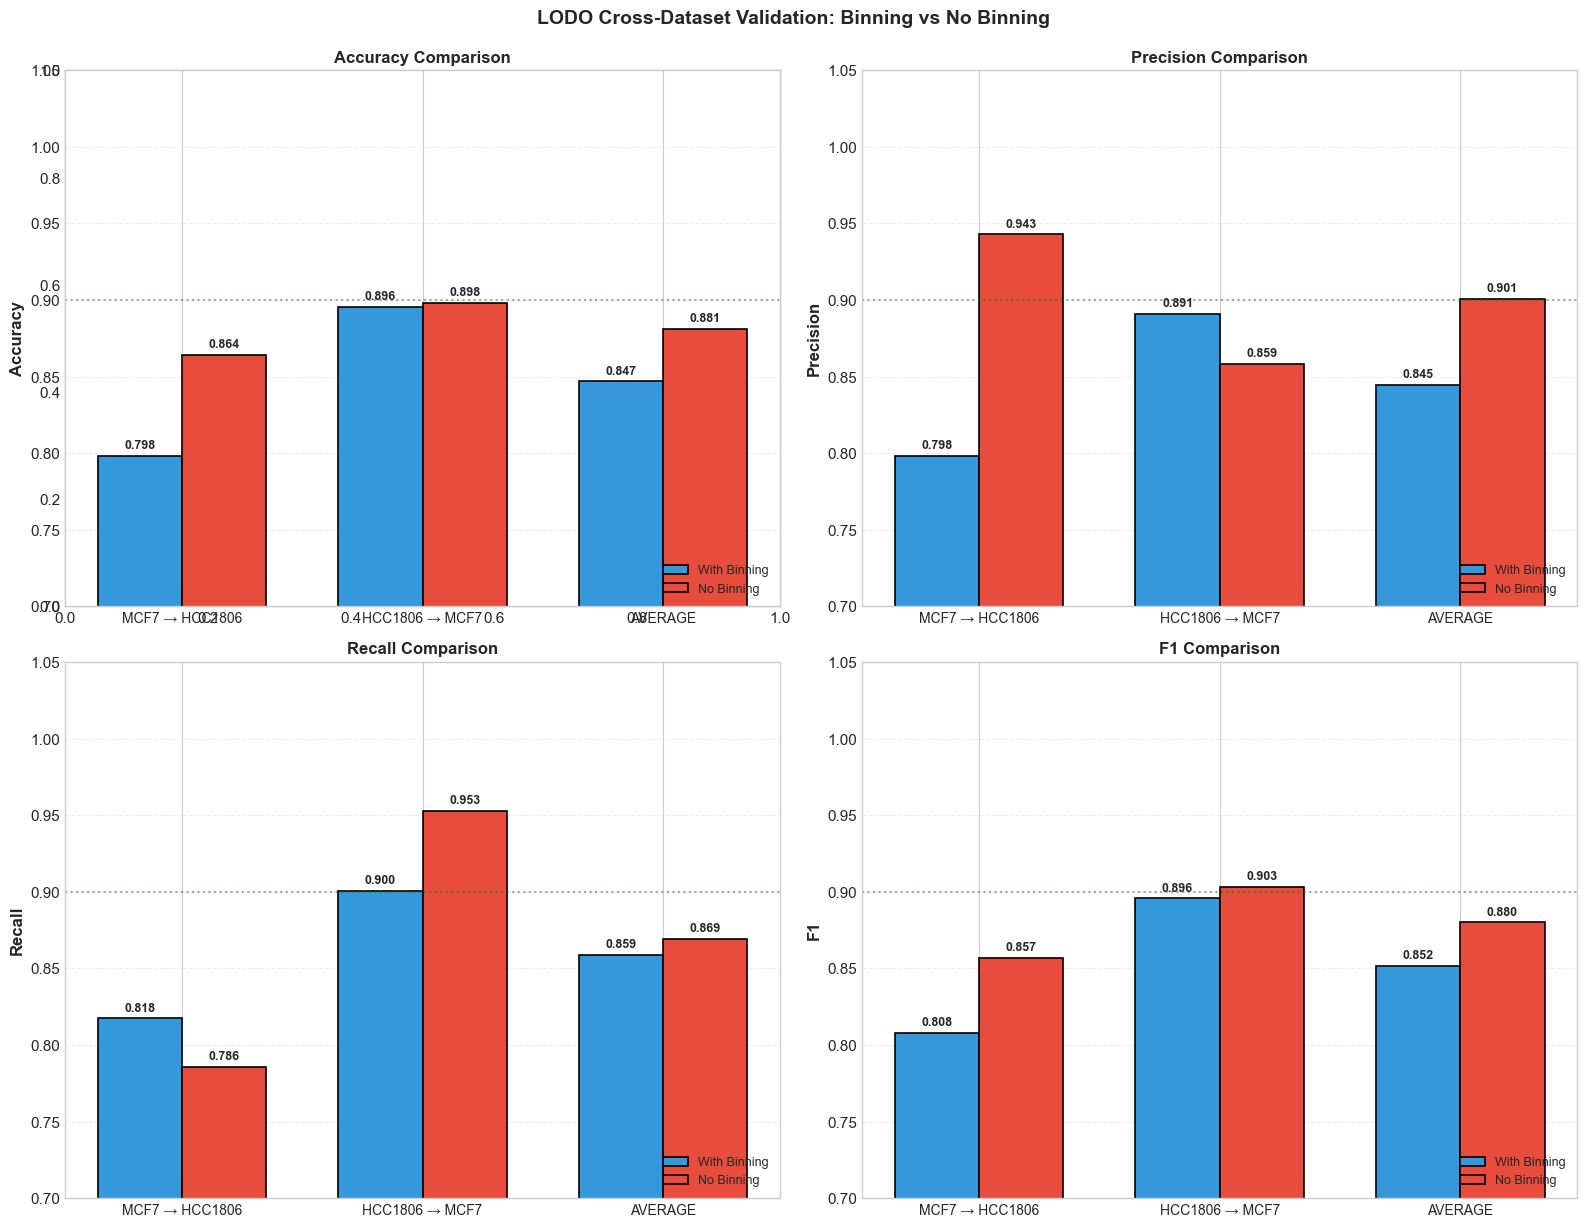

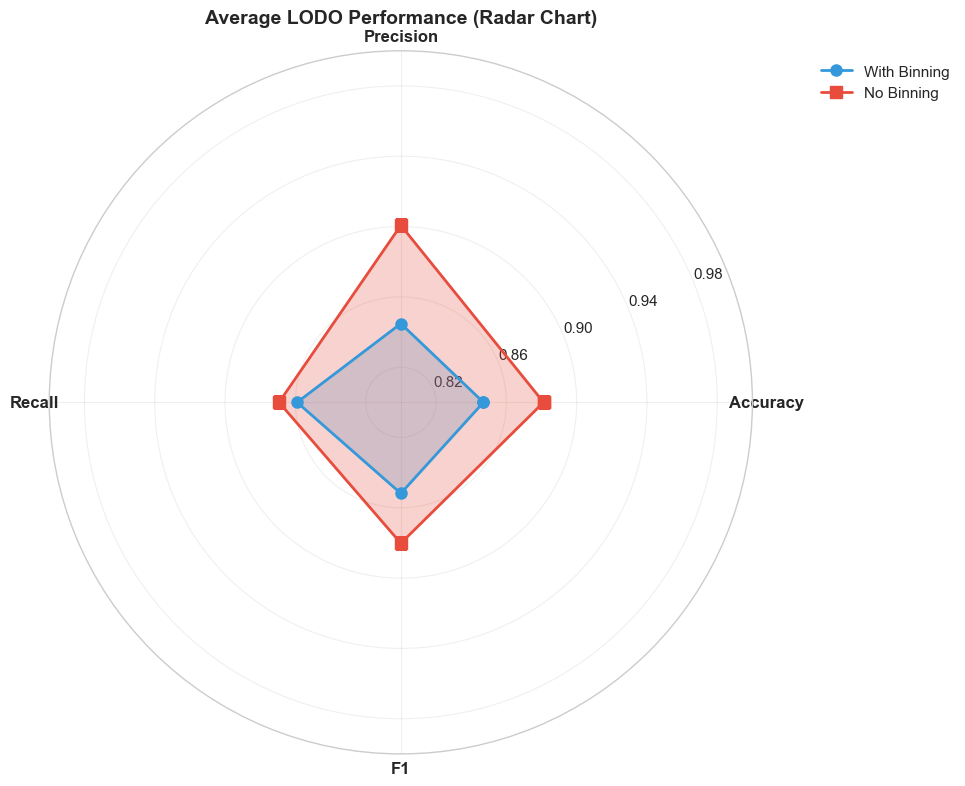

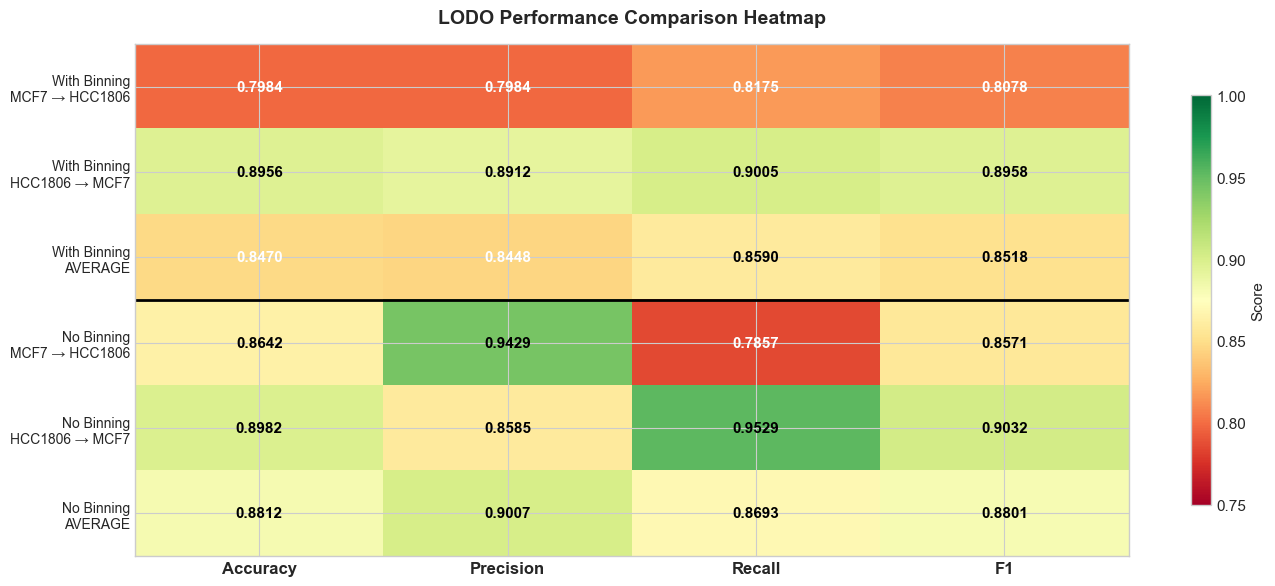

LODO COMPARISON SUMMARY: BINNING vs NO BINNING

----------------------------------------------------------------------
WITH BINNING (n_features=750, num_bins=300)
----------------------------------------------------------------------
Direction              Accuracy  Precision     Recall         F1
MCF7 → HCC1806           0.7984     0.7984     0.8175     0.8078
HCC1806 → MCF7           0.8956     0.8912     0.9005     0.8958
AVERAGE                  0.8470     0.8448     0.8590     0.8518

----------------------------------------------------------------------
NO BINNING (raw expression values)
----------------------------------------------------------------------
Direction              Accuracy  Precision     Recall         F1
MCF7 → HCC1806           0.8642     0.9429     0.7857     0.8571
HCC1806 → MCF7           0.8982     0.8585     0.9529     0.9032
AVERAGE                  0.8812     0.9007     0.8693     0.8801

-------------------------------------------------------------------

In [ ]:
# =============================================================================
# VISUALIZATION: BINNING+FEATURE SELECTION vs NO BINNING+NO FEATURE SELECTION
# =============================================================================

import matplotlib.pyplot as plt
import numpy as np

# Data from results
metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']

# With Binning + Feature Selection (from your results)
binning_mcf7_to_hcc = [0.7984, 0.7984, 0.8175, 0.8078, 0.8464]
binning_hcc_to_mcf7 = [0.8956, 0.8912, 0.9005, 0.8958, 0.9227]
binning_avg = [0.8470, 0.8448, 0.8590, 0.8518, 0.8845]

# No Binning + No Feature Selection (from your results)
# MCF7 → HCC1806: Acc=0.8642, Prec=0.9429, Rec=0.7857, F1=0.8571
# HCC1806 → MCF7: Acc=0.8982, Prec=0.8585, Rec=0.9529, F1=0.9032
no_binning_mcf7_to_hcc = [0.8642, 0.9429, 0.7857, 0.8571, None]  # AUC not provided
no_binning_hcc_to_mcf7 = [0.8982, 0.8585, 0.9529, 0.9032, None]
no_binning_avg = [(0.8642+0.8982)/2, (0.9429+0.8585)/2, (0.7857+0.9529)/2, (0.8571+0.9032)/2, None]

# Create figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

x = np.arange(len(metrics))
width = 0.35

# Colors
color_binning = '#2ecc71'      # Green for binning
color_no_binning = '#3498db'   # Blue for no binning

# =============================================================================
# Plot 1: MCF7 → HCC1806
# =============================================================================
ax1 = axes[0]
bars1 = ax1.bar(x - width/2, binning_mcf7_to_hcc, width, 
                label='With Binning + Feature Selection', color=color_binning, edgecolor='black')
bars2 = ax1.bar(x + width/2, [v if v else 0 for v in no_binning_mcf7_to_hcc], width, 
                label='No Binning + No Feature Selection', color=color_no_binning, edgecolor='black')

ax1.set_xlabel('Metrics', fontsize=12)
ax1.set_ylabel('Score', fontsize=12)
ax1.set_title('MCF7 → HCC1806', fontsize=14, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(metrics)
ax1.set_ylim(0, 1.1)
ax1.legend(loc='lower right', fontsize=9)
ax1.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)

# Add value labels
for bar in bars1:
    height = bar.get_height()
    ax1.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                 xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=8)
for i, bar in enumerate(bars2):
    if no_binning_mcf7_to_hcc[i] is not None:
        height = bar.get_height()
        ax1.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                     xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=8)

# =============================================================================
# Plot 2: HCC1806 → MCF7
# =============================================================================
ax2 = axes[1]
bars3 = ax2.bar(x - width/2, binning_hcc_to_mcf7, width, 
                label='With Binning + Feature Selection', color=color_binning, edgecolor='black')
bars4 = ax2.bar(x + width/2, [v if v else 0 for v in no_binning_hcc_to_mcf7], width, 
                label='No Binning + No Feature Selection', color=color_no_binning, edgecolor='black')

ax2.set_xlabel('Metrics', fontsize=12)
ax2.set_ylabel('Score', fontsize=12)
ax2.set_title('HCC1806 → MCF7', fontsize=14, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(metrics)
ax2.set_ylim(0, 1.1)
ax2.legend(loc='lower right', fontsize=9)
ax2.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)

# Add value labels
for bar in bars3:
    height = bar.get_height()
    ax2.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                 xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=8)
for i, bar in enumerate(bars4):
    if no_binning_hcc_to_mcf7[i] is not None:
        height = bar.get_height()
        ax2.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                     xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=8)

# =============================================================================
# Plot 3: AVERAGE (excluding AUC for no-binning since not available)
# =============================================================================
ax3 = axes[2]
metrics_avg = ['Accuracy', 'Precision', 'Recall', 'F1']
x_avg = np.arange(len(metrics_avg))

bars5 = ax3.bar(x_avg - width/2, binning_avg[:4], width, 
                label='With Binning + Feature Selection', color=color_binning, edgecolor='black')
bars6 = ax3.bar(x_avg + width/2, no_binning_avg[:4], width, 
                label='No Binning + No Feature Selection', color=color_no_binning, edgecolor='black')

ax3.set_xlabel('Metrics', fontsize=12)
ax3.set_ylabel('Score', fontsize=12)
ax3.set_title('AVERAGE (Both Directions)', fontsize=14, fontweight='bold')
ax3.set_xticks(x_avg)
ax3.set_xticklabels(metrics_avg)
ax3.set_ylim(0, 1.1)
ax3.legend(loc='lower right', fontsize=9)
ax3.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)

# Add value labels
for bar in bars5:
    height = bar.get_height()
    ax3.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                 xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=8)
for bar in bars6:
    height = bar.get_height()
    ax3.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                 xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=8)

plt.suptitle('LODO Cross-Dataset Generalization: Binning vs No Binning', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('lodo_binning_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# =============================================================================
# PRINT SUMMARY TABLE
# =============================================================================
print("\n" + "=" * 80)
print("SUMMARY: LODO CROSS-DATASET GENERALIZATION")
print("=" * 80)
print(f"\n{'Method':<45} {'Accuracy':<10} {'Precision':<10} {'Recall':<10} {'F1':<10}")
print("-" * 80)
print(f"{'With Binning + Feature Selection (Avg)':<45} {binning_avg[0]:<10.4f} {binning_avg[1]:<10.4f} {binning_avg[2]:<10.4f} {binning_avg[3]:<10.4f}")
print(f"{'No Binning + No Feature Selection (Avg)':<45} {no_binning_avg[0]:<10.4f} {no_binning_avg[1]:<10.4f} {no_binning_avg[2]:<10.4f} {no_binning_avg[3]:<10.4f}")
print("-" * 80)

# Calculate differences
print(f"\n{'Difference (Binning - No Binning)':<45}", end="")
for i in range(4):
    diff = binning_avg[i] - no_binning_avg[i]
    print(f" {diff:+.4f}   ", end="")
print()

Although the binning lost, the difference is not that bad given that the binned model has much less features...

## B.4 Combined (Pooled) Model with Binning

We now test whether binning might benefit the **pooled model** (where both cell lines are in the training set). This repeats the Part A pipeline but adds quantile binning as an additional preprocessing step.

The Optuna objective here is 5-fold stratified CV on the pooled training set (same as Part A), but the pipeline now includes: **binning -> feature selection -> stacking classifier** (no separate scaler, since binning already normalizes the scale).


### Implementation: Sklearn Transformer Wrapper for Binning

To integrate the binning function into a scikit-learn `Pipeline`, we wrap it in a custom `BaseEstimator`/`TransformerMixin` class. This allows binning to be applied consistently during both `fit` and `transform` phases and ensures compatibility with `cross_val_score` and Optuna.

In [8]:
# =============================================================================
# SKLEARN TRANSFORMER WRAPPER FOR EXISTING BINNING FUNCTION
# =============================================================================
from sklearn.base import BaseEstimator, TransformerMixin

class QuantileBinningTransformer(BaseEstimator, TransformerMixin):
    """
    Sklearn-compatible transformer wrapper for bin_expression_quantiles.
    Uses the existing function defined in the notebook.
    """
    def __init__(self, num_bins: int = 50, zero_as_bin0: bool = True):
        self.num_bins = num_bins
        self.zero_as_bin0 = zero_as_bin0
    
    def fit(self, X, y=None):
        # No fitting required - binning is computed per-cell at transform time
        return self
    
    def transform(self, X):
        # Call the existing bin_expression_quantiles function
        return bin_expression_quantiles(
            X, 
            num_bins=self.num_bins, 
            zero_as_bin0=self.zero_as_bin0
        ).astype(np.float32)
    
    def fit_transform(self, X, y=None):
        return self.fit(X, y).transform(X)

In [10]:
# =============================================================================
# OBJECTIVE FUNCTION: 5-FOLD STRATIFIED CV WITH QUANTILE BINNING
# =============================================================================

def objective(trial):
    """
    Optuna objective function for hyperparameter optimization.
    Uses quantile binning as the ONLY normalization method.
    Uses 5-fold stratified CV on the combined training set.
    """
    # ==========================================================================
    # PREPROCESSING HYPERPARAMETERS - BINNING ONLY
    # ==========================================================================
    
    # Number of features to select AFTER binning
    n_features = trial.suggest_int("n_features", 50, min(3000, MAX_FEATURES), step=150)
    
    # Number of quantile bins - MUST be less than n_features
    # Also reasonable to cap at a sensible maximum (e.g., 200)
    max_bins = n_features
    min_bins = 50  # Minimum reasonable bins
    
    if max_bins < min_bins:
        raise optuna.TrialPruned(f"n_features ({n_features}) too small for binning")
    
    num_bins = trial.suggest_int("num_bins", min_bins, max_bins, step=5)
    
    # Whether to treat zeros as bin 0
    zero_as_bin0 = trial.suggest_categorical("zero_as_bin0", [True, False])
    
    # ==========================================================================
    # MODEL SELECTION HYPERPARAMETERS
    # ==========================================================================
    
    use_lr = trial.suggest_categorical("use_lr", [True, False])
    use_svc = trial.suggest_categorical("use_svc", [True, False])
    use_xgb = trial.suggest_categorical("use_xgb", [True, False])
    use_cbc = trial.suggest_categorical("use_cbc", [True, False])
    
    if sum([use_lr, use_svc, use_xgb, use_cbc]) < 2:
        raise optuna.TrialPruned("Need at least 2 base estimators for stacking")
    
    params = {
        "use_lr": use_lr,
        "use_svc": use_svc,
        "use_xgb": use_xgb,
        "use_cbc": use_cbc,
    }
    
    if use_lr:
        params["lr_C"] = trial.suggest_float("lr_C", 0.01, 10.0, log=True)
    
    if use_svc:
        params["svc_C"] = trial.suggest_float("svc_C", 0.1, 100.0, log=True)
        params["svc_gamma"] = trial.suggest_float("svc_gamma", 1e-4, 1e-1, log=True)
    
    if use_xgb:
        params["xgb_depth"] = trial.suggest_int("xgb_depth", 2, 4)
        params["xgb_lr"] = trial.suggest_float("xgb_lr", 0.1, 0.5)
        params["xgb_n_estimators"] = trial.suggest_int("xgb_n_estimators", 100, 600, step=50)
        params["xgb_reg_alpha"] = trial.suggest_float("xgb_reg_alpha", 0.1, 10.0, log=True)
        params["xgb_reg_lambda"] = trial.suggest_float("xgb_reg_lambda", 0.1, 10.0, log=True)
    
    if use_cbc:
        params["cbc_depth"] = trial.suggest_int("cbc_depth", 2, 6)
        params["cbc_lr"] = trial.suggest_float("cbc_lr", 0.1, 0.5)
        params["cbc_iterations"] = trial.suggest_int("cbc_iterations", 100, 600, step=50)
        params["cbc_l2_reg"] = trial.suggest_float("cbc_l2_reg", 1.0, 10.0)
    
    params["final_estimator"] = trial.suggest_categorical("final_estimator", ["lr", "rf"])
    
    # ==========================================================================
    # 5-FOLD STRATIFIED CV ON COMBINED TRAINING SET
    # ==========================================================================
    
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    
    try:
        scores = []
        for train_idx, val_idx in cv.split(X_combined_train, stratify_labels_train):
            X_train, X_val = X_combined_train[train_idx], X_combined_train[val_idx]
            y_train, y_val = y_combined_train[train_idx], y_combined_train[val_idx]
            
            # Pipeline: Binning -> Feature Selection -> Stacking Classifier
            pipeline = Pipeline([
                ("binning", QuantileBinningTransformer(num_bins=num_bins, zero_as_bin0=zero_as_bin0)),
                ("selector", SelectKBest(f_classif, k=n_features)),
                ("stacking", create_stacking_classifier(params))
            ])
            pipeline.fit(X_train, y_train)
            scores.append(pipeline.score(X_val, y_val))
        
        mean_score = np.mean(scores)
        trial.set_user_attr("cv_std", np.std(scores))
        trial.set_user_attr("num_bins", num_bins)
        trial.set_user_attr("n_features", n_features)
        
        return mean_score
        
    except Exception as e:
        print(f"Trial failed: {e}")
        raise optuna.TrialPruned(f"Trial failed: {e}")

In [14]:
USE_WANDB = False

In [17]:
# =============================================================================
# RUN OPTUNA HYPERPARAMETER SEARCH WITH BINNING
# =============================================================================

def run_optuna_study(n_trials=100, use_wandb=False):
    study = optuna.create_study(
        direction="maximize",
        study_name="combined_train_cv_binning",
        sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
    )
    
    callbacks = []
    if use_wandb:
        wandb.init(project="combined-train-cv-binning", config={"n_trials": n_trials}, reinit=True)
        wandb_callback = WeightsAndBiasesCallback(metric_name="cv_accuracy")
        callbacks.append(wandb_callback)
    
    study.optimize(objective, n_trials=n_trials, callbacks=callbacks, show_progress_bar=True)
    
    if use_wandb:
        wandb.finish()
    
    return study

print("=" * 60)
print("HYPERPARAMETER SEARCH: QUANTILE BINNING NORMALIZATION")
print("=" * 60)
print(f"Training set: {X_combined_train.shape[0]} samples")
print(f"Features: {X_combined_train.shape[1]}")
print(f"Held-out test: MCF7={len(y_mcf7_test)}, HCC1806={len(y_hcc1806_test)}")
print("Normalization: Quantile Binning (num_bins is a hyperparameter)")
print("=" * 60)

N_TRIALS = 250
study = run_optuna_study(n_trials=N_TRIALS, use_wandb=USE_WANDB)

[I 2026-02-04 17:14:36,922] A new study created in memory with name: combined_train_cv_binning


HYPERPARAMETER SEARCH: QUANTILE BINNING NORMALIZATION
Training set: 526 samples
Features: 20501
Held-out test: MCF7=50, HCC1806=50
Normalization: Quantile Binning (num_bins is a hyperparameter)


  0%|          | 0/250 [00:00<?, ?it/s]

[I 2026-02-04 17:14:36,924] Trial 0 pruned. Need at least 2 base estimators for stacking


Best trial: 1. Best value: 0.963863:   1%|          | 2/250 [01:10<2:26:37, 35.47s/it]

...

Best trial: 16. Best value: 0.979119:  36%|███▋      | 91/250 [3:04:12<7:03:47, 159.92s/it]

[I 2026-02-04 20:18:49,179] Trial 90 finished with value: 0.9601257861635221 and parameters: {'n_features': 1850, 'num_bins': 870, 'zero_as_bin0': False, 'use_lr': False, 'use_svc': True, 'use_xgb': True, 'use_cbc': False, 'svc_C': 81.04270143770898, 'svc_gamma': 0.00533751680010976, 'xgb_depth': 4, 'xgb_lr': 0.25239418557741333, 'xgb_n_estimators': 200, 'xgb_reg_alpha': 2.3668791236443014, 'xgb_reg_lambda': 3.112801828266634, 'final_estimator': 'rf'}. Best is trial 16 with value: 0.9791194968553458.


Best trial: 16. Best value: 0.979119:  36%|███▋      | 91/250 [3:06:32<5:25:55, 122.99s/it]


[W 2026-02-04 20:21:08,941] Trial 91 failed with parameters: {'n_features': 2300, 'num_bins': 1675, 'zero_as_bin0': False, 'use_lr': True, 'use_svc': True, 'use_xgb': True, 'use_cbc': False, 'lr_C': 0.8083361145706942, 'svc_C': 99.29285597584106, 'svc_gamma': 0.07319293551128558, 'xgb_depth': 2, 'xgb_lr': 0.21779889286737117, 'xgb_n_estimators': 200, 'xgb_reg_alpha': 2.434327475761531, 'xgb_reg_lambda': 4.540238308574443, 'final_estimator': 'rf'} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "c:\Users\avsd8\AppData\Local\Programs\Python\Python310\lib\site-packages\optuna\study\_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
  File "C:\Users\avsd8\AppData\Local\Temp\ipykernel_30748\1638784822.py", line 91, in objective
    scores.append(pipeline.score(X_val, y_val))
  File "c:\Users\avsd8\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\pipeline.py", line 1185, in score
    Xt = transform.transfor

KeyboardInterrupt: 

In [18]:
# =============================================================================
# RETRAIN BEST MODEL ON FULL TRAINING SET AND EVALUATE ON HELD-OUT TEST
# =============================================================================

# Best hyperparameters from Optuna search
best_params = {
    'n_features': 1250, 
    'num_bins': 785, 
    'zero_as_bin0': False, 
    'use_lr': True, 
    'use_svc': True, 
    'use_xgb': True, 
    'use_cbc': False, 
    'lr_C': 0.08455514380553067, 
    'svc_C': 0.470727913203118, 
    'svc_gamma': 0.00011071059851959068, 
    'xgb_depth': 4, 
    'xgb_lr': 0.14090508908908764, 
    'xgb_n_estimators': 350, 
    'xgb_reg_alpha': 0.7117813815359552, 
    'xgb_reg_lambda': 0.4498933603798493, 
    'final_estimator': 'rf'
}

# Extract binning parameters
best_num_bins = best_params["num_bins"]
best_zero_as_bin0 = best_params["zero_as_bin0"]
best_n_features = best_params["n_features"]

# Build params dict for stacking classifier
model_params = {
    "use_lr": best_params["use_lr"],
    "use_svc": best_params["use_svc"],
    "use_xgb": best_params["use_xgb"],
    "use_cbc": best_params["use_cbc"],
    "final_estimator": best_params["final_estimator"],
}

if best_params["use_lr"]:
    model_params["lr_C"] = best_params["lr_C"]

if best_params["use_svc"]:
    model_params["svc_C"] = best_params["svc_C"]
    model_params["svc_gamma"] = best_params["svc_gamma"]

if best_params["use_xgb"]:
    model_params["xgb_depth"] = best_params["xgb_depth"]
    model_params["xgb_lr"] = best_params["xgb_lr"]
    model_params["xgb_n_estimators"] = best_params["xgb_n_estimators"]
    model_params["xgb_reg_alpha"] = best_params["xgb_reg_alpha"]
    model_params["xgb_reg_lambda"] = best_params["xgb_reg_lambda"]

if best_params["use_cbc"]:
    model_params["cbc_depth"] = best_params["cbc_depth"]
    model_params["cbc_lr"] = best_params["cbc_lr"]
    model_params["cbc_iterations"] = best_params["cbc_iterations"]
    model_params["cbc_l2_reg"] = best_params["cbc_l2_reg"]

# Create final pipeline with best parameters
final_pipeline = Pipeline([
    ("binning", QuantileBinningTransformer(num_bins=best_num_bins, zero_as_bin0=best_zero_as_bin0)),
    ("selector", SelectKBest(f_classif, k=best_n_features)),
    ("stacking", create_stacking_classifier(model_params))
])

# Train on full combined training set
print("Training final model on full training set...")
print(f"  Binning: num_bins={best_num_bins}, zero_as_bin0={best_zero_as_bin0}")
print(f"  Features: {best_n_features}")
print(f"  Models: LR={best_params['use_lr']}, SVC={best_params['use_svc']}, XGB={best_params['use_xgb']}, CBC={best_params['use_cbc']}")
print()

final_pipeline.fit(X_combined_train, y_combined_train)
print("Training complete!")

Training final model on full training set...
  Binning: num_bins=785, zero_as_bin0=False
  Features: 1250
  Models: LR=True, SVC=True, XGB=True, CBC=False

Training complete!


In [19]:
# =============================================================================
# EVALUATE ON HELD-OUT TEST SETS
# =============================================================================

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, roc_auc_score

print("=" * 60)
print("HELD-OUT TEST SET EVALUATION")
print("=" * 60)

# MCF7 Test
y_pred_mcf7 = final_pipeline.predict(X_mcf7_test)
y_proba_mcf7 = final_pipeline.predict_proba(X_mcf7_test)[:, 1]
acc_mcf7 = accuracy_score(y_mcf7_test, y_pred_mcf7)
f1_mcf7 = f1_score(y_mcf7_test, y_pred_mcf7)
auc_mcf7 = roc_auc_score(y_mcf7_test, y_proba_mcf7)

print(f"\nMCF7 Test Set ({len(y_mcf7_test)} samples):")
print(f"  Accuracy: {acc_mcf7:.4f}")
print(f"  F1 Score: {f1_mcf7:.4f}")
print(f"  AUC-ROC:  {auc_mcf7:.4f}")
print(classification_report(y_mcf7_test, y_pred_mcf7, target_names=["Normoxia", "Hypoxia"]))

# HCC1806 Test
y_pred_hcc1806 = final_pipeline.predict(X_hcc1806_test)
y_proba_hcc1806 = final_pipeline.predict_proba(X_hcc1806_test)[:, 1]
acc_hcc1806 = accuracy_score(y_hcc1806_test, y_pred_hcc1806)
f1_hcc1806 = f1_score(y_hcc1806_test, y_pred_hcc1806)
auc_hcc1806 = roc_auc_score(y_hcc1806_test, y_proba_hcc1806)

print(f"\nHCC1806 Test Set ({len(y_hcc1806_test)} samples):")
print(f"  Accuracy: {acc_hcc1806:.4f}")
print(f"  F1 Score: {f1_hcc1806:.4f}")
print(f"  AUC-ROC:  {auc_hcc1806:.4f}")
print(classification_report(y_hcc1806_test, y_pred_hcc1806, target_names=["Normoxia", "Hypoxia"]))

# Combined Test
X_combined_test = np.vstack([X_mcf7_test, X_hcc1806_test])
y_combined_test = np.concatenate([y_mcf7_test, y_hcc1806_test])
y_pred_combined = final_pipeline.predict(X_combined_test)
y_proba_combined = final_pipeline.predict_proba(X_combined_test)[:, 1]
acc_combined = accuracy_score(y_combined_test, y_pred_combined)
f1_combined = f1_score(y_combined_test, y_pred_combined)
auc_combined = roc_auc_score(y_combined_test, y_proba_combined)

print(f"\nCombined Test Set ({len(y_combined_test)} samples):")
print(f"  Accuracy: {acc_combined:.4f}")
print(f"  F1 Score: {f1_combined:.4f}")
print(f"  AUC-ROC:  {auc_combined:.4f}")

# Average across both test sets
avg_accuracy = (acc_mcf7 + acc_hcc1806) / 2
avg_f1 = (f1_mcf7 + f1_hcc1806) / 2
avg_auc = (auc_mcf7 + auc_hcc1806) / 2

print("\n" + "=" * 60)
print("SUMMARY")
print("=" * 60)
print(f"CV Accuracy (Training):   0.9791")
print(f"MCF7 Test Accuracy:       {acc_mcf7:.4f}")
print(f"HCC1806 Test Accuracy:    {acc_hcc1806:.4f}")
print(f"Average Test Accuracy:    {avg_accuracy:.4f}")
print(f"Combined Test Accuracy:   {acc_combined:.4f}")
print(f"\nBest Binning Config: num_bins={best_num_bins}, zero_as_bin0={best_zero_as_bin0}")

HELD-OUT TEST SET EVALUATION

MCF7 Test Set (50 samples):
  Accuracy: 0.9400
  F1 Score: 0.9362
  AUC-ROC:  1.0000
              precision    recall  f1-score   support

    Normoxia       0.89      1.00      0.94        25
     Hypoxia       1.00      0.88      0.94        25

    accuracy                           0.94        50
   macro avg       0.95      0.94      0.94        50
weighted avg       0.95      0.94      0.94        50


HCC1806 Test Set (50 samples):
  Accuracy: 0.9600
  F1 Score: 0.9615
  AUC-ROC:  0.9944
              precision    recall  f1-score   support

    Normoxia       0.96      0.96      0.96        24
     Hypoxia       0.96      0.96      0.96        26

    accuracy                           0.96        50
   macro avg       0.96      0.96      0.96        50
weighted avg       0.96      0.96      0.96        50


Combined Test Set (100 samples):
  Accuracy: 0.9500
  F1 Score: 0.9495
  AUC-ROC:  0.9970

SUMMARY
CV Accuracy (Training):   0.9791
MCF7 Test

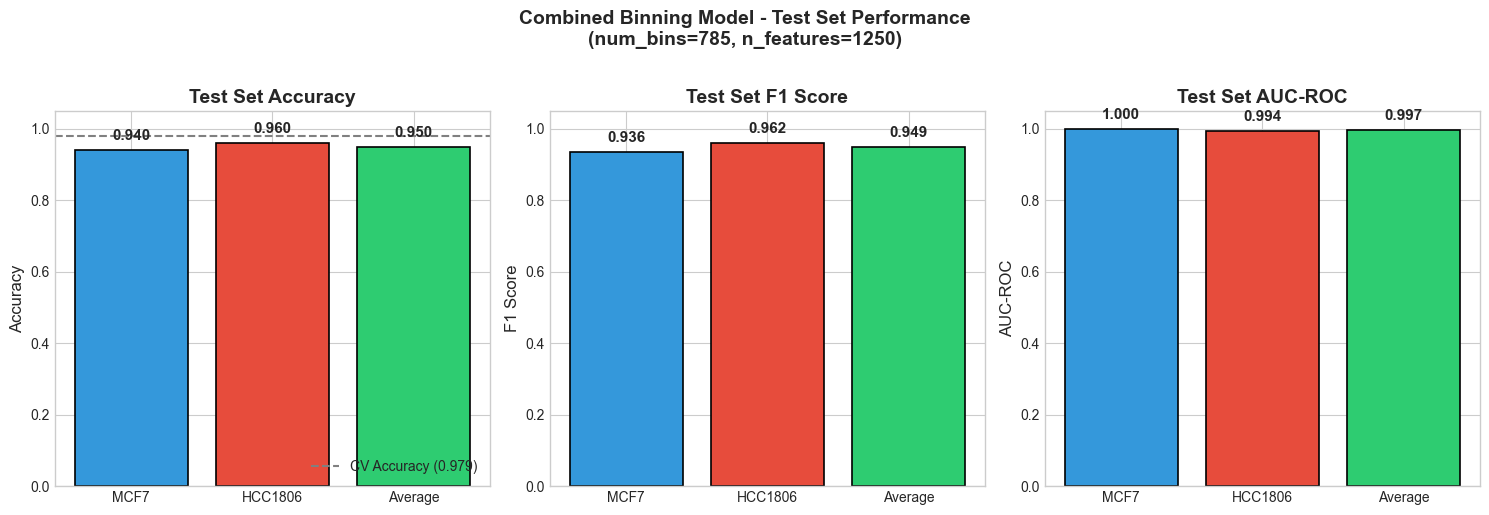

In [21]:
# =============================================================================
# VISUALIZATION: PERFORMANCE COMPARISON
# =============================================================================

import matplotlib.pyplot as plt
import seaborn as sns

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Data for plotting
cell_lines = ['MCF7', 'HCC1806', 'Average']
accuracies = [acc_mcf7, acc_hcc1806, avg_accuracy]
f1_scores = [f1_mcf7, f1_hcc1806, avg_f1]
auc_scores = [auc_mcf7, auc_hcc1806, avg_auc]

colors = ['#3498db', '#e74c3c', '#2ecc71']

# Plot 1: Accuracy
ax1 = axes[0]
bars1 = ax1.bar(cell_lines, accuracies, color=colors, edgecolor='black', linewidth=1.2)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.set_title('Test Set Accuracy', fontsize=14, fontweight='bold')
ax1.set_ylim(0, 1.05)
ax1.axhline(y=0.9791, color='gray', linestyle='--', linewidth=1.5, label='CV Accuracy (0.979)')
ax1.legend(loc='lower right')
for bar, val in zip(bars1, accuracies):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
             f'{val:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Plot 2: F1 Score
ax2 = axes[1]
bars2 = ax2.bar(cell_lines, f1_scores, color=colors, edgecolor='black', linewidth=1.2)
ax2.set_ylabel('F1 Score', fontsize=12)
ax2.set_title('Test Set F1 Score', fontsize=14, fontweight='bold')
ax2.set_ylim(0, 1.05)
for bar, val in zip(bars2, f1_scores):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
             f'{val:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Plot 3: AUC-ROC
ax3 = axes[2]
bars3 = ax3.bar(cell_lines, auc_scores, color=colors, edgecolor='black', linewidth=1.2)
ax3.set_ylabel('AUC-ROC', fontsize=12)
ax3.set_title('Test Set AUC-ROC', fontsize=14, fontweight='bold')
ax3.set_ylim(0, 1.05)
for bar, val in zip(bars3, auc_scores):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
             f'{val:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.suptitle('Combined Binning Model - Test Set Performance\n(num_bins=785, n_features=1250)', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('binning_model_performance.png', dpi=150, bbox_inches='tight')
plt.show()

---
# Part C: Final Evaluation on New Train/Test Split
---

## Final Comparison: Three Best Models on a Fresh Train/Test Split

To ensure a fair, unbiased comparison, all three best models are retrained and evaluated on the **same fresh train/test split** (independent of splits used during hyperparameter tuning). This eliminates any potential data leakage from the tuning phase.

**Evaluation protocol for all three models:**
1. Combine HCC1806 + MCF7 **training** data.
2. Train each model's full pipeline on the combined training set.
3. Predict on the held-out HCC1806 and MCF7 **test** sets separately.
4. Report per-cell-line metrics and average across both test sets.

**The three models being compared:**

| Model | Preprocessing | Features | Base Estimators | Meta-Learner |
|-------|--------------|----------|-----------------|-------------|
| **Combined (No Binning)** | Power scaler (Yeo-Johnson) | 450 genes | LR + SVC | Logistic Regression |
| **LODO Binning Model** | 300 quantile bins, no scaler | 750 genes | LR + SVC | Random Forest |
| **Combined (With Binning)** | 785 quantile bins (zero_as_bin0=False), no scaler | 1,250 genes | LR + SVC + XGBoost | Random Forest |

In [12]:
# =============================================================================
# STEP 1: PREPROCESS TRAIN/TEST DATA & ALIGN FEATURES
# =============================================================================
# NOTE: Requires prior cells to have been run (imports, create_label,
#       bin_expression_quantiles, get_scaler, create_stacking_classifier).
# NOTE: df_hcc1806_raw_train, df_mcf7_raw_train, df_hcc1806_raw_test,
#       df_mcf7_raw_test must already be loaded from the cells above.
# =============================================================================

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42

def preprocess_for_eval(df_raw):
    """
    Transpose gene x sample matrix to sample x gene format.
    Adds PERC_NONZERO_VALUES feature.
    Adds LABEL column only if column names contain 'Hyp'/'Norm' markers.
    """
    labels = create_label(df_raw)
    df_t = df_raw.T.copy()
    df_t.columns = [str(c).replace('"', '') for c in df_t.columns]
    df_t["PERC_NONZERO_VALUES"] = [
        1000 * (df_raw[col] > 0).sum() / len(df_raw[col])
        for col in df_raw.columns
    ]
    # Only add LABEL if we got a label for every sample
    if len(labels) == len(df_t):
        df_t["LABEL"] = labels
    return df_t

# Process all 4 datasets
df_hcc_train_proc = preprocess_for_eval(df_hcc1806_raw_train)
df_mcf_train_proc = preprocess_for_eval(df_mcf7_raw_train)
df_hcc_test_proc  = preprocess_for_eval(df_hcc1806_raw_test)
df_mcf_test_proc  = preprocess_for_eval(df_mcf7_raw_test)

has_test_labels = ("LABEL" in df_hcc_test_proc.columns and
                   "LABEL" in df_mcf_test_proc.columns)

print(f"Train HCC1806: {df_hcc_train_proc.shape}")
print(f"Train MCF7:    {df_mcf_train_proc.shape}")
print(f"Test HCC1806:  {df_hcc_test_proc.shape}")
print(f"Test MCF7:     {df_mcf_test_proc.shape}")
print(f"Test labels available: {has_test_labels}")

# =====================================================================
# Find common genes across ALL 4 datasets
# =====================================================================
non_feature = {"LABEL", "PERC_NONZERO_VALUES"}
common_genes_eval = sorted(
    (set(df_hcc_train_proc.columns) - non_feature) &
    (set(df_mcf_train_proc.columns) - non_feature) &
    (set(df_hcc_test_proc.columns)  - non_feature) &
    (set(df_mcf_test_proc.columns)  - non_feature)
)
feature_cols_eval = common_genes_eval + ["PERC_NONZERO_VALUES"]
print(f"\nCommon genes across all datasets: {len(common_genes_eval)}")
print(f"Total features (genes + PERC_NONZERO): {len(feature_cols_eval)}")

# =====================================================================
# Extract numpy arrays
# =====================================================================
X_hcc_tr = df_hcc_train_proc[feature_cols_eval].values.astype(np.float32)
y_hcc_tr = df_hcc_train_proc["LABEL"].values.astype(np.int32)
X_mcf_tr = df_mcf_train_proc[feature_cols_eval].values.astype(np.float32)
y_mcf_tr = df_mcf_train_proc["LABEL"].values.astype(np.int32)

# Combined train
X_comb_tr = np.vstack([X_hcc_tr, X_mcf_tr])
y_comb_tr = np.concatenate([y_hcc_tr, y_mcf_tr])

# Test
X_hcc_te = df_hcc_test_proc[feature_cols_eval].values.astype(np.float32)
X_mcf_te = df_mcf_test_proc[feature_cols_eval].values.astype(np.float32)
y_hcc_te = df_hcc_test_proc["LABEL"].values.astype(np.int32) if has_test_labels else None
y_mcf_te = df_mcf_test_proc["LABEL"].values.astype(np.int32) if has_test_labels else None

print(f"\nCombined train: {X_comb_tr.shape[0]} samples "
      f"({X_hcc_tr.shape[0]} HCC + {X_mcf_tr.shape[0]} MCF7) x {X_comb_tr.shape[1]} features")
print(f"Train labels: Normo={int(sum(y_comb_tr==0))}, Hypo={int(sum(y_comb_tr==1))}")
print(f"HCC test: {X_hcc_te.shape[0]} samples")
print(f"MCF7 test: {X_mcf_te.shape[0]} samples")

Train HCC1806: (182, 3002)
Train MCF7:    (250, 3002)
Test HCC1806:  (45, 3001)
Test MCF7:     (63, 3001)
Test labels available: False

Common genes across all datasets: 1208
Total features (genes + PERC_NONZERO): 1209

Combined train: 432 samples (182 HCC + 250 MCF7) x 1209 features
Train labels: Normo=211, Hypo=221
HCC test: 45 samples
MCF7 test: 63 samples


In [18]:
# =============================================================================
# STEP 2: TRAIN & EVALUATE ALL THREE BEST MODELS  +  SAVE TO EXCEL
# =============================================================================

# Sample names from the transposed test dataframes (row index = original col names)
hcc_test_samples = list(df_hcc_test_proc.index)
mcf_test_samples = list(df_mcf_test_proc.index)


def evaluate_model(name, params, X_train, y_train, X_te_h, X_te_m,
                   apply_binning=False, num_bins=None, zero_as_bin0=True):
    """
    Build pipeline with best hyperparameters, train on combined data,
    predict on separate HCC1806 and MCF7 test sets.
    Returns dict with predictions and sample-level DataFrames.
    """
    print(f"\n{'='*70}")
    print(f"  {name}")
    print(f"{'='*70}")

    # ----- Apply binning BEFORE the pipeline if requested -----
    if apply_binning and num_bins is not None:
        print(f"  Binning: num_bins={num_bins}, zero_as_bin0={zero_as_bin0}")
        X_tr = bin_expression_quantiles(
            X_train.copy(), num_bins=num_bins, zero_as_bin0=zero_as_bin0
        ).astype(np.float32)
        X_h = bin_expression_quantiles(
            X_te_h.copy(), num_bins=num_bins, zero_as_bin0=zero_as_bin0
        ).astype(np.float32)
        X_m = bin_expression_quantiles(
            X_te_m.copy(), num_bins=num_bins, zero_as_bin0=zero_as_bin0
        ).astype(np.float32)
    else:
        X_tr, X_h, X_m = X_train, X_te_h, X_te_m

    # ----- Build pipeline: scaler -> feature selection -> stacking -----
    scaler_name = params.get("scaler", "none")
    n_feat = min(params.get("n_features", 450), X_tr.shape[1])

    pipe = Pipeline([
        ("scaler", get_scaler(scaler_name)),
        ("selector", SelectKBest(f_classif, k=n_feat)),
        ("stacking", create_stacking_classifier(params))
    ])

    print(f"  Scaler: {scaler_name}")
    print(f"  Selected features: {n_feat}")
    print(f"  Training on {X_tr.shape[0]} samples...")
    pipe.fit(X_tr, y_train)
    print(f"  Training complete!")

    # ----- Predict -----
    pred_h = pipe.predict(X_h)
    pred_m = pipe.predict(X_m)

    print(f"\n  Predictions:")
    print(f"  HCC1806: {int(sum(pred_h==1))} Hypoxia / {int(sum(pred_h==0))} Normoxia (n={len(pred_h)})")
    print(f"  MCF7:    {int(sum(pred_m==1))} Hypoxia / {int(sum(pred_m==0))} Normoxia (n={len(pred_m)})")

    # ----- Build per-sample DataFrames -----
    label_map = {0: "Normoxia", 1: "Hypoxia"}

    df_hcc_pred = pd.DataFrame({
        "Sample": hcc_test_samples,
        "Dataset": "HCC1806",
        "Predicted_Label": pred_h,
        "Predicted_Class": [label_map[p] for p in pred_h]
    })

    df_mcf_pred = pd.DataFrame({
        "Sample": mcf_test_samples,
        "Dataset": "MCF7",
        "Predicted_Label": pred_m,
        "Predicted_Class": [label_map[p] for p in pred_m]
    })

    # Combine HCC + MCF7 into one table for this model
    df_combined_pred = pd.concat([df_hcc_pred, df_mcf_pred], ignore_index=True)

    return {
        "name": name,
        "pred_hcc": pred_h,
        "pred_mcf": pred_m,
        "df_predictions": df_combined_pred
    }


# =====================================================================
# MODEL 1: Combined No Binning
# Best trial 95 with value: 0.9809
# =====================================================================
params_1 = {
    'scaler': 'power',
    'n_features': 450,
    'use_lr': True,
    'use_svc': True,
    'use_xgb': False,
    'use_cbc': False,
    'lr_C': 4.42350732731447,
    'svc_C': 3.5425060288657226,
    'svc_gamma': 0.00036403459223931456,
    'final_estimator': 'lr'
}

results_1 = evaluate_model(
    "Combined No Binning", params_1,
    X_comb_tr, y_comb_tr,
    X_hcc_te, X_mcf_te
)


# =====================================================================
# MODEL 2: Separate + Binning (num_bins=300)
# =====================================================================
params_2 = {
    'scaler': 'none',
    'n_features': 750,
    'use_lr': True,
    'use_svc': True,
    'use_xgb': False,
    'use_cbc': False,
    'lr_C': 0.010091823932181944,
    'svc_C': 0.3121029115112667,
    'svc_gamma': 0.0065788844943278375,
    'final_estimator': 'rf'
}

results_2 = evaluate_model(
    "Separate + Binning (num_bins=300)", params_2,
    X_comb_tr, y_comb_tr,
    X_hcc_te, X_mcf_te,
    apply_binning=True, num_bins=300, zero_as_bin0=True
)


# =====================================================================
# MODEL 3: Combined With Binning (num_bins=785, zero_as_bin0=False)
# =====================================================================
params_3 = {
    'scaler': 'none',
    'n_features': 1250,
    'use_lr': True,
    'use_svc': True,
    'use_xgb': True,
    'use_cbc': False,
    'lr_C': 0.08455514380553067,
    'svc_C': 0.470727913203118,
    'svc_gamma': 0.00011071059851959068,
    'xgb_depth': 4,
    'xgb_lr': 0.14090508908908764,
    'xgb_n_estimators': 350,
    'xgb_reg_alpha': 0.7117813815359552,
    'xgb_reg_lambda': 0.4498933603798493,
    'final_estimator': 'rf'
}

results_3 = evaluate_model(
    "Combined With Binning (num_bins=785, zero_as_bin0=False)", params_3,
    X_comb_tr, y_comb_tr,
    X_hcc_te, X_mcf_te,
    apply_binning=True, num_bins=785, zero_as_bin0=False
)


# =====================================================================
# SAVE ALL PREDICTIONS TO EXCEL (one sheet per model)
# =====================================================================
output_path = r"C:\Users\avsd8\Downloads\model_predictions.xlsx"

all_results = [results_1, results_2, results_3]

# Clean sheet names (Excel limits to 31 chars)
sheet_names = [
    "Combined_NoBinning",
    "Separate_Binning_300",
    "Combined_Binning_785"
]

with pd.ExcelWriter(output_path, engine="openpyxl") as writer:
    for res, sheet in zip(all_results, sheet_names):
        res["df_predictions"].to_excel(writer, sheet_name=sheet, index=False)

print(f"\n\n{'='*70}")
print(f"  PREDICTIONS SAVED")
print(f"{'='*70}")
print(f"  File: {output_path}")
print(f"  Sheets:")
for res, sheet in zip(all_results, sheet_names):
    df = res["df_predictions"]
    n_hypo = int(sum(df["Predicted_Label"] == 1))
    n_norm = int(sum(df["Predicted_Label"] == 0))
    print(f"    {sheet}: {len(df)} samples ({n_hypo} Hypoxia, {n_norm} Normoxia)")
print(f"\n  Each sheet has columns: Sample | Dataset | Predicted_Label | Predicted_Class")


  Combined No Binning
  Scaler: power
  Selected features: 450
  Training on 432 samples...
  Training complete!

  Predictions:
  HCC1806: 19 Hypoxia / 26 Normoxia (n=45)
  MCF7:    31 Hypoxia / 32 Normoxia (n=63)

  Separate + Binning (num_bins=300)
  Binning: num_bins=300, zero_as_bin0=True
  Scaler: none
  Selected features: 750
  Training on 432 samples...
  Training complete!

  Predictions:
  HCC1806: 19 Hypoxia / 26 Normoxia (n=45)
  MCF7:    31 Hypoxia / 32 Normoxia (n=63)

  Combined With Binning (num_bins=785, zero_as_bin0=False)
  Binning: num_bins=785, zero_as_bin0=False
  Scaler: none
  Selected features: 1209
  Training on 432 samples...
  Training complete!

  Predictions:
  HCC1806: 20 Hypoxia / 25 Normoxia (n=45)
  MCF7:    31 Hypoxia / 32 Normoxia (n=63)


  PREDICTIONS SAVED
  File: C:\Users\avsd8\Downloads\model_predictions.xlsx
  Sheets:
    Combined_NoBinning: 108 samples (50 Hypoxia, 58 Normoxia)
    Separate_Binning_300: 108 samples (50 Hypoxia, 58 Normoxia)
 